## Data Prep & Preview

### 0. Data loading

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
from pathlib import Path
from src.evaluation.feature_screener import FeatureScreener
from src.pipeline import DataPipeline

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
import shap

In [2]:
# 1. Load the fresh training data directly from DuckDB (v_d2_training view)
pipeline = DataPipeline()
print("Loading v_d2_training from DuckDB...")
df = pipeline.load_training_data_from_db()
print(f"Loaded {len(df):,} rows.")

Loading v_d2_training from DuckDB...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded 12,233 rows.


In [3]:
# ==========================================
# TEMP BLOCK: Calculate Missing Deltas
# Run this immediately after loading your raw dataframe, 
# BEFORE executing any of your feature drop lists.
# ==========================================

print("Calculating missing delta features...")

# Mapping: New Delta Column -> (Current Value Column, Lag1 Column)
# Note: Case sensitivity matters here, matching your exact dataframe columns
delta_pairs = {
    'natr_Delta': ('natr', 'natr_lag1'),
    'consolidation_width_Delta': ('consolidation_width', 'consolidation_width_lag1'),
    'low_52w_Delta': ('Low_52W', 'low_52w_lag1'), 
    'highest_high_20d_Delta': ('highest_high_20d', 'highest_high_20d_lag1'),
    'rsi_14_Delta': ('RSI_14', 'rsi_14_lag1'),

    # The Keepers
    'vcp_ratio_Delta': ('VCP_Ratio', 'vcp_ratio_lag1'),
    'rs_Delta': ('rs', 'rs_lag1'),
    'rs_ma_Delta': ('rs_ma', 'rs_ma_lag1'),
    'dry_up_volume_Delta': ('Dry_Up_Volume', 'dry_up_volume_lag1'),
    'lowest_low_20d_Delta': ('lowest_low_20d', 'lowest_low_20d_lag1'),
    
    # The Drops (Calculated here just for completion before pruning)
    'atr_Delta': ('ATR', 'atr_lag1'),
    'high_52w_Delta': ('High_52W', 'high_52w_lag1'),
    'price_vs_sma_200_Delta': ('price_vs_sma_200', 'price_vs_sma_200_lag1'),
    'dist_from_52w_low_Delta': ('Dist_From_52W_Low', 'dist_from_52w_low_lag1'),
    'dist_from_20d_low_Delta': ('Dist_From_20D_Low', 'dist_from_20d_low_lag1')
}

# 1. Calculate the standard deltas
for delta_col, (base_col, lag_col) in delta_pairs.items():
    # We do a case-insensitive check just in case DuckDB/pandas casing is slightly off
    base_match = [c for c in df.columns if c.lower() == base_col.lower()]
    lag_match = [c for c in df.columns if c.lower() == lag_col.lower()]
    
    if base_match and lag_match:
        # Simple subtraction (Current - Yesterday)
        df[delta_col] = df[base_match[0]] - df[lag_match[0]]
        print(f"✅ Created: {delta_col}")
    else:
        print(f"⚠️ Skipped {delta_col} - missing base {base_col} or lag {lag_col}")

# 2. Recreate the pure 1-day return if it's missing
if 'return_1d' not in df.columns:
    close_match = [c for c in df.columns if c.lower() == 'close']
    if close_match and 'ticker' in df.columns:
        # Must group by ticker so we don't calculate returns across different stocks
        df = df.sort_values(by=['ticker', 'date']) # Ensure chronological order
        df['return_1d'] = df.groupby('ticker')[close_match[0]].pct_change()
        print("✅ Created: return_1d")
    else:
        print("⚠️ Could not create return_1d (missing 'close' or 'ticker')")

print("Delta calculations complete. You may now proceed to drop the lag1 and raw columns.")
# ==========================================

Calculating missing delta features...
✅ Created: natr_Delta
✅ Created: consolidation_width_Delta
✅ Created: low_52w_Delta
✅ Created: highest_high_20d_Delta
✅ Created: rsi_14_Delta
✅ Created: vcp_ratio_Delta
✅ Created: rs_Delta
✅ Created: rs_ma_Delta
✅ Created: dry_up_volume_Delta
✅ Created: lowest_low_20d_Delta
✅ Created: atr_Delta
✅ Created: high_52w_Delta
✅ Created: price_vs_sma_200_Delta
✅ Created: dist_from_52w_low_Delta
✅ Created: dist_from_20d_low_Delta
Delta calculations complete. You may now proceed to drop the lag1 and raw columns.


In [4]:
# print("Engineering interaction features...")

# # 1. Stochastic-style Base Location (handling potential zero-division)
# df['price_location_in_base'] = np.where(
#     df['consolidation_width'] > 0,
#     df['Dist_From_20D_Low'] / df['consolidation_width'],
#     0
# )

# # 2. Momentum Acceleration (6-month vs 9-month)
# # Using a spread handles negative momentum values cleanly
# df['mom_acceleration_6m_9m'] = df['mom_126d'] - df['mom_189d']

# # 3. Moving Average Convergence/Divergence
# # Subtracting the longer-term distance from the shorter-term distance
# df['sma_150_200_spread'] = df['price_vs_sma_150'] - df['price_vs_sma_200']

# # Drop the raw components that have now been captured by the interactions
# # Note: mom_189d will be dropped in your main correlation block due to RS overlap.

# # 1. Daily Delta Excess Spreads
# df['excess_sma50_delta'] = df['Price_vs_SMA_50_Delta'] - df['return_1d']
# df['excess_sma150_delta'] = df['Price_vs_SMA_150_Delta'] - df['return_1d']
# df['excess_sma200_delta'] = df['price_vs_sma_200_delta'] - df['return_1d']
# df['excess_rs_line_delta'] = df['rs_line_delta'] - df['return_1d']
# df['excess_20d_low_delta'] = df['dist_from_20d_low_delta'] - df['return_1d']
# df['excess_52w_low_delta'] = df['dist_from_52w_low_delta'] - df['return_1d']

# # 2. Relative Velocity Premium
# df['relative_velocity_premium'] = df['rs_velocity'] - df['return_5d']

# # 3. Structural Divergence
# df['momentum_vs_base_depth'] = df['mom_189d'] - df['Dist_From_52W_Low']

# # 4. Sector Leadership Premium
# df['sector_leadership_premium'] = df['rs_rating'] - df['RS_Sector_Rank']

# # 5. Breakout Direction Skew
# df['breakout_direction_skew'] = df['highest_high_20d_delta'] - df['consolidation_width_delta']

# # --- The Final Drop List ---
# # Now that the relationships are captured, drop the redundant raw components
# INTERACTION_DROPS = [
#     'Price_vs_SMA_50_Delta', 
#     'Price_vs_SMA_150_Delta', 
#     'price_vs_sma_200_delta', 
#     'dist_from_20d_low_delta', 
#     'dist_from_52w_low_delta', 
#     'rs_line_delta',
#     'rs_velocity',
#     'mom_189d',
#     'RS_Sector_Rank',
#     'RS_vs_Sector',
#     'highest_high_20d_delta',
#     'high_52w_delta', # Orphaned geometric metric
#     'Dist_From_20D_Low',      
#     'mom_126d',               
#     'price_vs_sma_150'
# ]

Dataset Shape: (12233, 260)


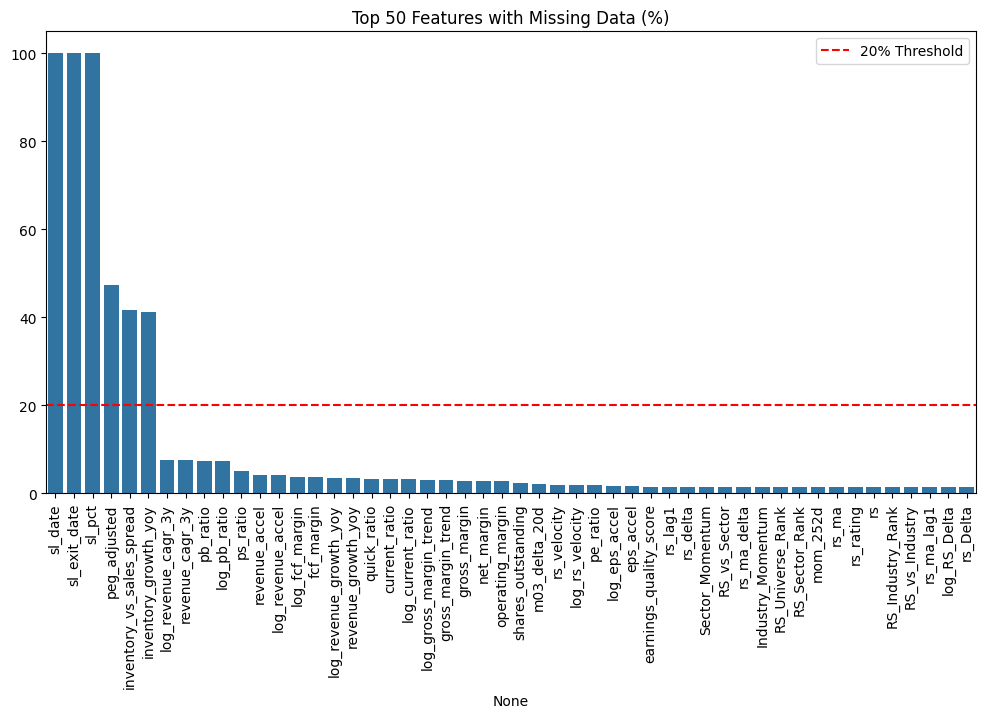

In [5]:
print(f"Dataset Shape: {df.shape}")

# 1. Calculate missingness
missing_stats = df.isnull().mean() * 100
missing_stats = missing_stats[missing_stats > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
if not missing_stats.empty:
    sns.barplot(x=missing_stats.index[:50], y=missing_stats.values[:50]) # Top 30 worst
    plt.xticks(rotation=90)
    plt.title("Top 50 Features with Missing Data (%)")
    plt.axhline(20, color='r', linestyle='--', label='20% Threshold')
    plt.legend()
    plt.show()
else:
    print("No missing data found!")

cols_missing = missing_stats[missing_stats > 20].index.tolist()


In [6]:
import collections

# 1. Find all columns that match when converted to lowercase
col_counts = collections.Counter([c.lower() for c in df.columns])
duplicate_bases = [col for col, count in col_counts.items() if count > 1]

# 2. Print the exact pairs creating the collision
print("--- Case-Insensitive Duplicates Found ---")
for base in duplicate_bases:
    collisions = [c for c in df.columns if c.lower() == base]
    print(f"Collision for '{base}': {collisions}")
    
# 3. Optional: Auto-drop the TitleCase versions (keeping the lowercase DuckDB defaults)
drops = [c for c in df.columns if c.lower() in duplicate_bases and c != c.lower()]

--- Case-Insensitive Duplicates Found ---
Collision for 'natr_delta': ['natr_delta', 'natr_Delta']
Collision for 'vcp_ratio_delta': ['vcp_ratio_delta', 'vcp_ratio_Delta']
Collision for 'consolidation_width_delta': ['consolidation_width_delta', 'consolidation_width_Delta']
Collision for 'price_vs_sma_200_delta': ['price_vs_sma_200_delta', 'price_vs_sma_200_Delta']
Collision for 'rs_delta': ['rs_delta', 'rs_Delta']
Collision for 'rs_ma_delta': ['rs_ma_delta', 'rs_ma_Delta']
Collision for 'dry_up_volume_delta': ['dry_up_volume_delta', 'dry_up_volume_Delta']
Collision for 'high_52w_delta': ['high_52w_delta', 'high_52w_Delta']
Collision for 'low_52w_delta': ['low_52w_delta', 'low_52w_Delta']
Collision for 'lowest_low_20d_delta': ['lowest_low_20d_delta', 'lowest_low_20d_Delta']
Collision for 'highest_high_20d_delta': ['highest_high_20d_delta', 'highest_high_20d_Delta']
Collision for 'rsi_14_delta': ['rsi_14_delta', 'rsi_14_Delta']
Collision for 'dist_from_52w_low_delta': ['dist_from_52w_low_

### 1. Warm-up Period Clipping

In [ ]:
min_date = df['entry_date'].min()
max_date = df['entry_date'].max()
print(f"Original Date Range: {min_date} to {max_date}")
print(f"Total Rows: {len(df)}")

WARMUP_DAYS = 365 
df['entry_date'] = pd.to_datetime(df['entry_date'])
min_dates_per_ticker = df.groupby('ticker')['entry_date'].transform('min')
df = df[
    (df['entry_date'] >= (min_dates_per_ticker + pd.Timedelta(days=WARMUP_DAYS))) & 
    (df['exit_date'] <= '2026-01-30')
].copy()

print(f"Rows after dropping {WARMUP_DAYS}-day warmup per ticker: {len(df)}")

### 2. EDA and Feature Engineering

In [8]:
missing_cols = missing_stats[missing_stats > 20].index.tolist()
log_cols = [col for col in df.columns if col.startswith('log_')]
lag_cols = [col for col in df.columns if col.endswith('_lag1')]
delta_cols = [col for col in df.columns if col.endswith('_Delta')]

leakage_cols = [
    # Leakage & Targets
    'entry_date', 'exit_date', 'return_pct', 'target', 'days_held', 'return_at_exit',
    'holding_days', 'MAE', 'days_observed', 'MFE', 'exit_price', 'entry_price', 
    'mae_date', 'mfe_date', 'mae_holding', 'mfe_holding', 'sl_pct', 'sl_date', 
    'sl_exit_date', 'target_class',
    # Raw & Unused
    'close', 'market_cap', 
    'peg_adjusted', 'inventory_vs_sales_spread', 'inventory_growth_yoy'
]

raw_cols = [
    # --- 1. Absolute Price Levels ---
    # The model should never know the actual dollar price of a stock.
    'Open', 'High', 'Low', 'Close',
    
    # --- 2. Absolute Moving Averages ---
    # These are in dollar terms. (Keep 'price_vs_sma_50' instead).
    'sma_20', 'SMA_50', 'SMA_150', 'SMA_200', 'sma_200_lag20',
    
    # --- 3. Absolute Highs & Lows ---
    # Dollar-value peaks and troughs. (Keep 'pct_above_low_52w' instead).
    'High_52W', 'Low_52W', 'high_52w_lag1', 'low_52w_lag1',
    'high_20d', 'highest_high_20d', 'highest_high_20d_lag1', 
    'lowest_low_20d', 'lowest_low_20d_lag1',
    
    # --- 4. Absolute Volume & Liquidity ---
    # Raw share counts and dollar volume scale massively over time and across different stocks.
    # (Keep relative versions like 'Vol_Ratio' or 'turnover_acceleration').
    'Volume', 'vol_ma20', 'vol_ma50', 'vol_avg_50', 'Vol_MA',
    'Turnover', 'turnover_ma20', 'dollar_volume_avg_20',
    
    # --- 5. Absolute Fundamentals ---
    # Raw accounting numbers heavily favor mega-caps. 
    # (Keep ratios like 'debt_to_equity' or 'revenue_growth_yoy' instead).
    'revenue', 'net_income', 'total_assets', 'total_equity', 
    'market_cap', 'shares_outstanding', 'freeCashFlow', 'operatingCashFlow',
    
    # --- 6. Log Duplicates (From our earlier discussion) ---
    # If you still have these in the dataframe from EDA, drop them before training.
    # e.g., 'log_pb_ratio', 'log_volume_velocity', 'log_alpha001'
]


REDUNDANCY_DROPS = [
    # Static Lags (Slow-moving, but keep delta)
    'dist_from_52w_low_lag1', 'dist_from_20d_high_lag1', 'consolidation_width_lag1', 
    'dry_up_volume_lag1', 'vcp_ratio_lag1', 'price_vs_sma_150_lag1', 
    'price_vs_sma_200_lag1', 'atr_lag1', 'natr_lag1', 'rs_lag1',
    
    # Volatility Duplicates
    'ATR', 'atr_14', 'adr_20d', 'volatility_20d',
    
    # Geometric Duplicates (same as dist)
    'pct_above_low_52w', 'pct_from_high_52w', 'RS_Universe_Rank', 
    'price_momentum_curve', # r=1.000 with immediate_thrust
    
    # SPY Relative Noise
    'price_vs_spy', 'rs_line_log', 'price_vs_spy_ma20', 'price_vs_spy_ma50', 
    'price_vs_spy_ma63', 'price_vs_spy_ma200',
    
    # Fundamental Duplicates
    'net_margin'
]

FINAL_STRAGGLER_DROPS = [
    'vol_ratio_50', 
    'price_momentum_curve', 
    'return_20d', 
    'return_60d',
    'quick_ratio', 
    'alpha051',
    'rs_ma_lag1',  # Caught one more lag in the printout!
    'trend_ok'
]

log_cols = [col for col in df.columns if col.startswith('log_')]

exclude_cols = list(set(leakage_cols + raw_cols + REDUNDANCY_DROPS + FINAL_STRAGGLER_DROPS + missing_cols + log_cols + lag_cols + drops))

In [9]:
print("Assessing multicollinearity across all candidate features...")

# 2. Dynamically select all numeric features NOT in the exclusion list
available_features = [
    col for col in df.columns 
    if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])
]

print(f"Total features evaluating: {len(available_features)}")

Assessing multicollinearity across all candidate features...
Total features evaluating: 109


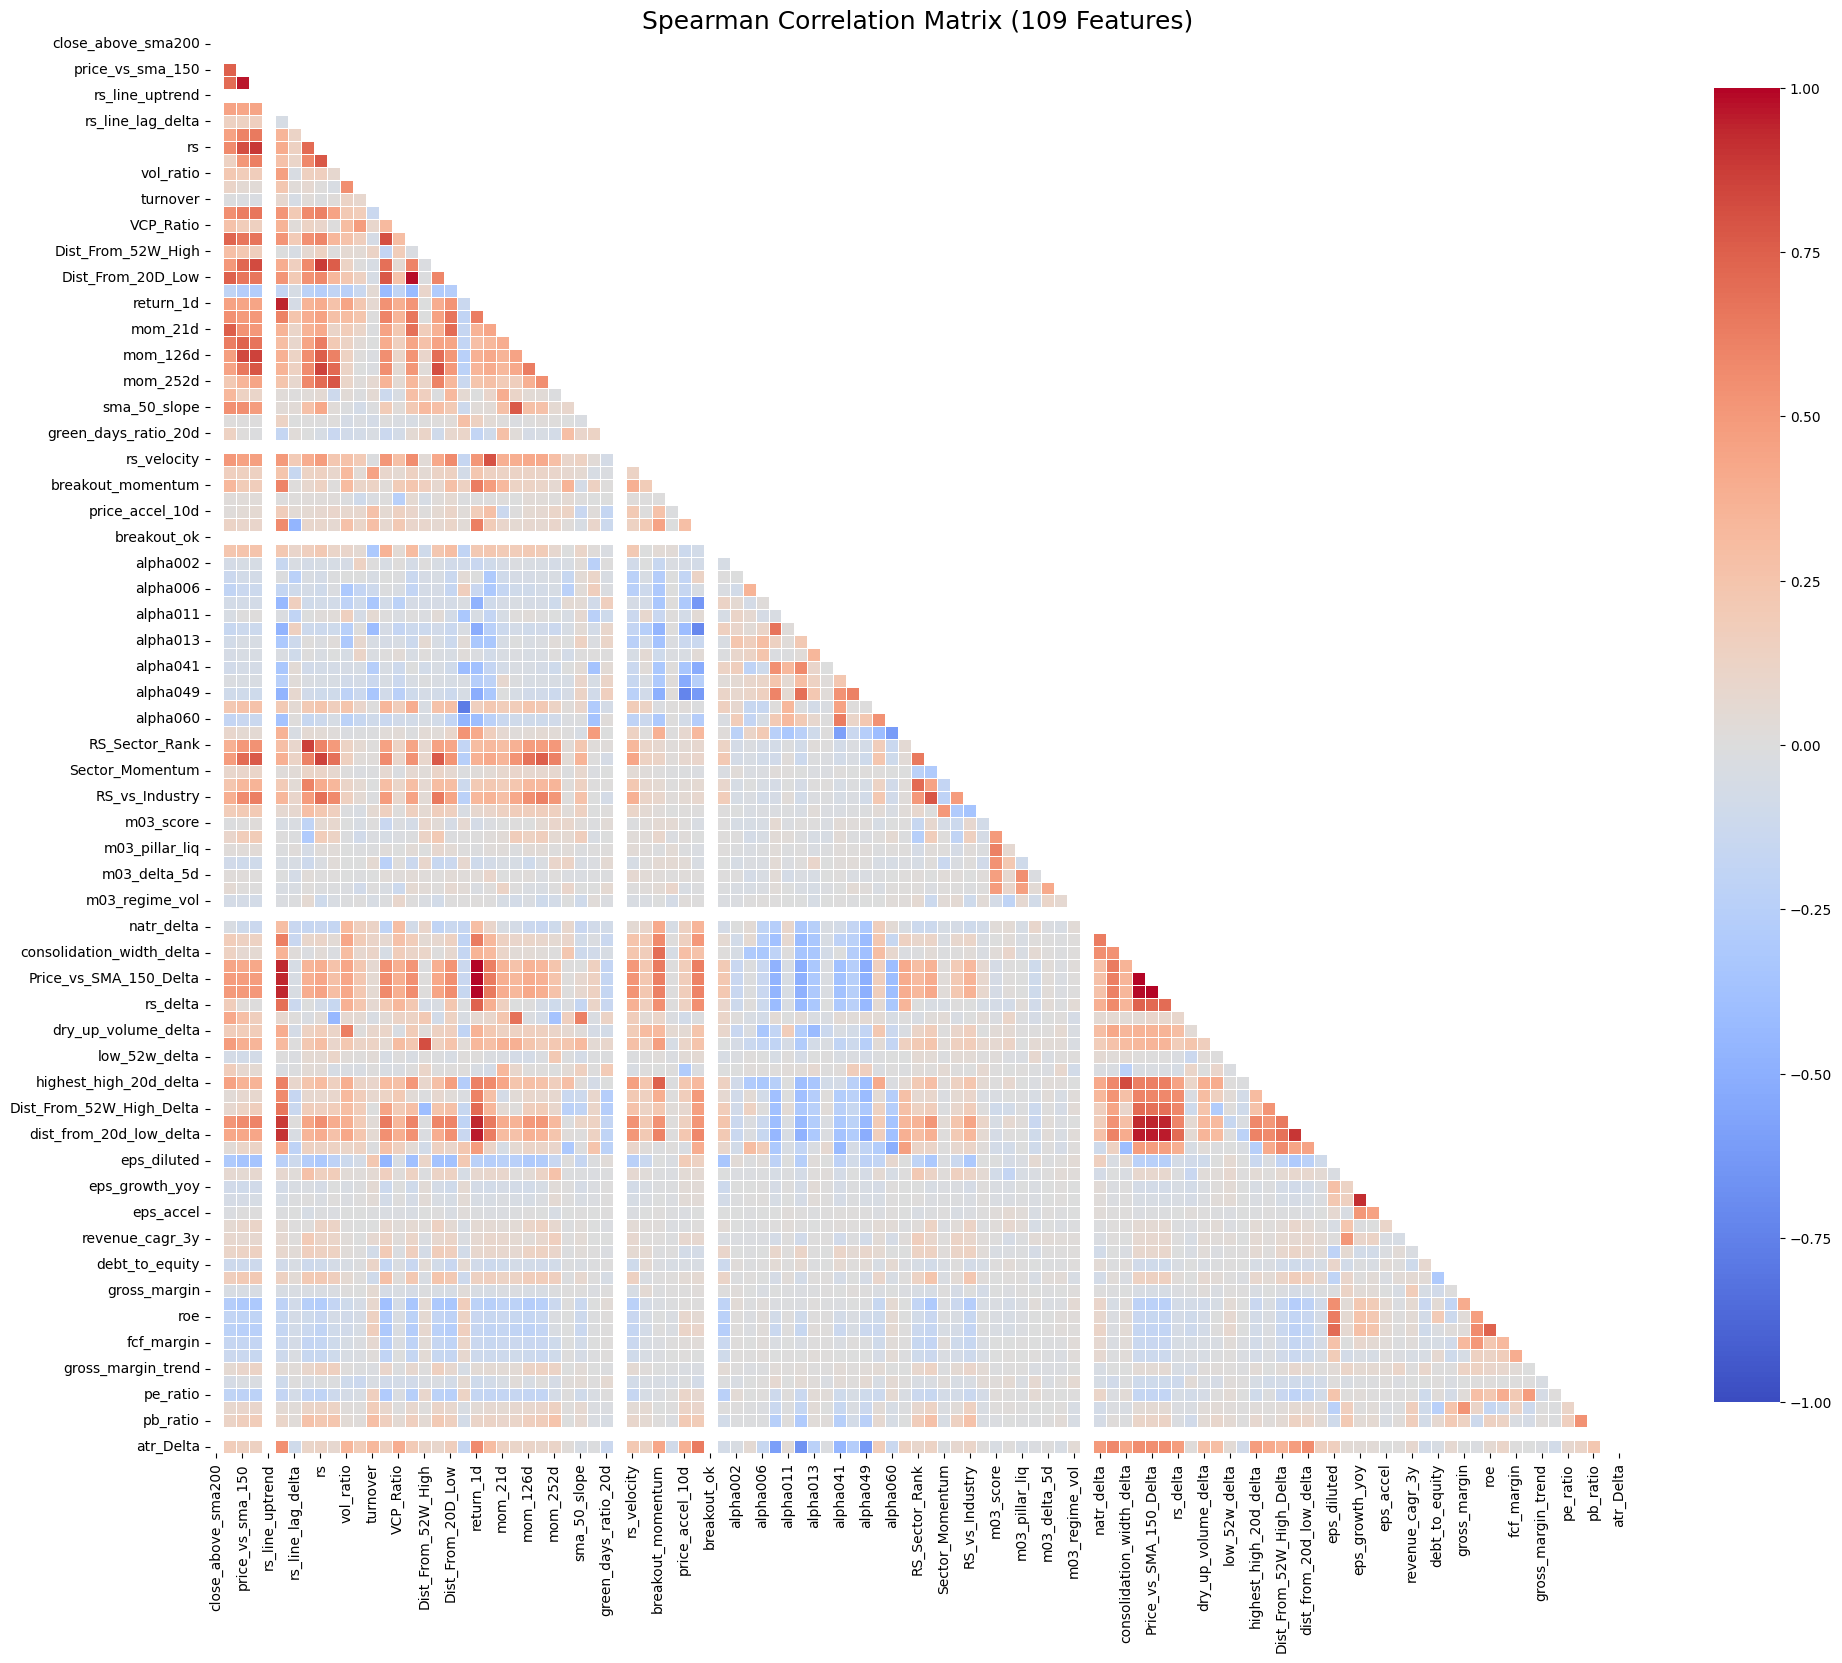


--- Highly Correlated Pairs (|r| > 0.80) ---
These pairs contain highly redundant information.
Recommendation: Keep the one with the higher univariate predictive power (or KS score) and drop the other.

[price_vs_sma_200_delta] vs [Price_vs_SMA_150_Delta] --> r = 0.999
[Price_vs_SMA_50_Delta] vs [return_1d] --> r = 0.996
[Price_vs_SMA_150_Delta] vs [return_1d] --> r = 0.995
[Price_vs_SMA_150_Delta] vs [Price_vs_SMA_50_Delta] --> r = 0.994
[price_vs_sma_200_delta] vs [return_1d] --> r = 0.993
[price_vs_sma_200_delta] vs [Price_vs_SMA_50_Delta] --> r = 0.992
[Dist_From_20D_Low] vs [consolidation_width] --> r = 0.977
[price_vs_sma_200] vs [price_vs_sma_150] --> r = 0.967
[dist_from_20d_low_delta] vs [return_1d] --> r = 0.956
[dist_from_20d_low_delta] vs [Price_vs_SMA_50_Delta] --> r = 0.956
[dist_from_20d_low_delta] vs [Price_vs_SMA_150_Delta] --> r = 0.954
[dist_from_20d_low_delta] vs [price_vs_sma_200_delta] --> r = 0.953
[dist_from_52w_low_delta] vs [price_vs_sma_200_delta] --> r = 0.

In [10]:
# 3. Calculate Spearman correlation (rank-based)
corr_matrix = df[available_features].corr(method='spearman')

# 4. Plot the heatmap
plt.figure(figsize=(20, 18)) # Enlarged for full feature set
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Only show lower triangle

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=False,       # Turned OFF: 100+ features will make annotations unreadable
    cmap="coolwarm",   # Red for highly positive, Blue for highly negative
    vmin=-1, vmax=1, 
    center=0,
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8}
)
plt.title(f"Spearman Correlation Matrix ({len(available_features)} Features)", fontsize=18)
plt.tight_layout()
plt.show()

# 5. --- Auto-Detect High Collinearity Pairs ---
print("\n--- Highly Correlated Pairs (|r| > 0.80) ---")
print("These pairs contain highly redundant information.")
print("Recommendation: Keep the one with the higher univariate predictive power (or KS score) and drop the other.\n")

threshold = 0.80

# Efficiently extract and sort the highly correlated pairs
corr_pairs = corr_matrix.where(
    np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool)
).stack()

# Filter by threshold and sort by absolute magnitude (highest correlations first)
highly_correlated = corr_pairs[abs(corr_pairs) > threshold].sort_values(key=abs, ascending=False)

if highly_correlated.empty:
    print("No highly correlated pairs found above the threshold. All features seem sufficiently independent.")
else:
    for (feat_i, feat_j), corr_val in highly_correlated.items():
        print(f"[{feat_i}] vs [{feat_j}] --> r = {corr_val:.3f}")

### 3. Target Distribution

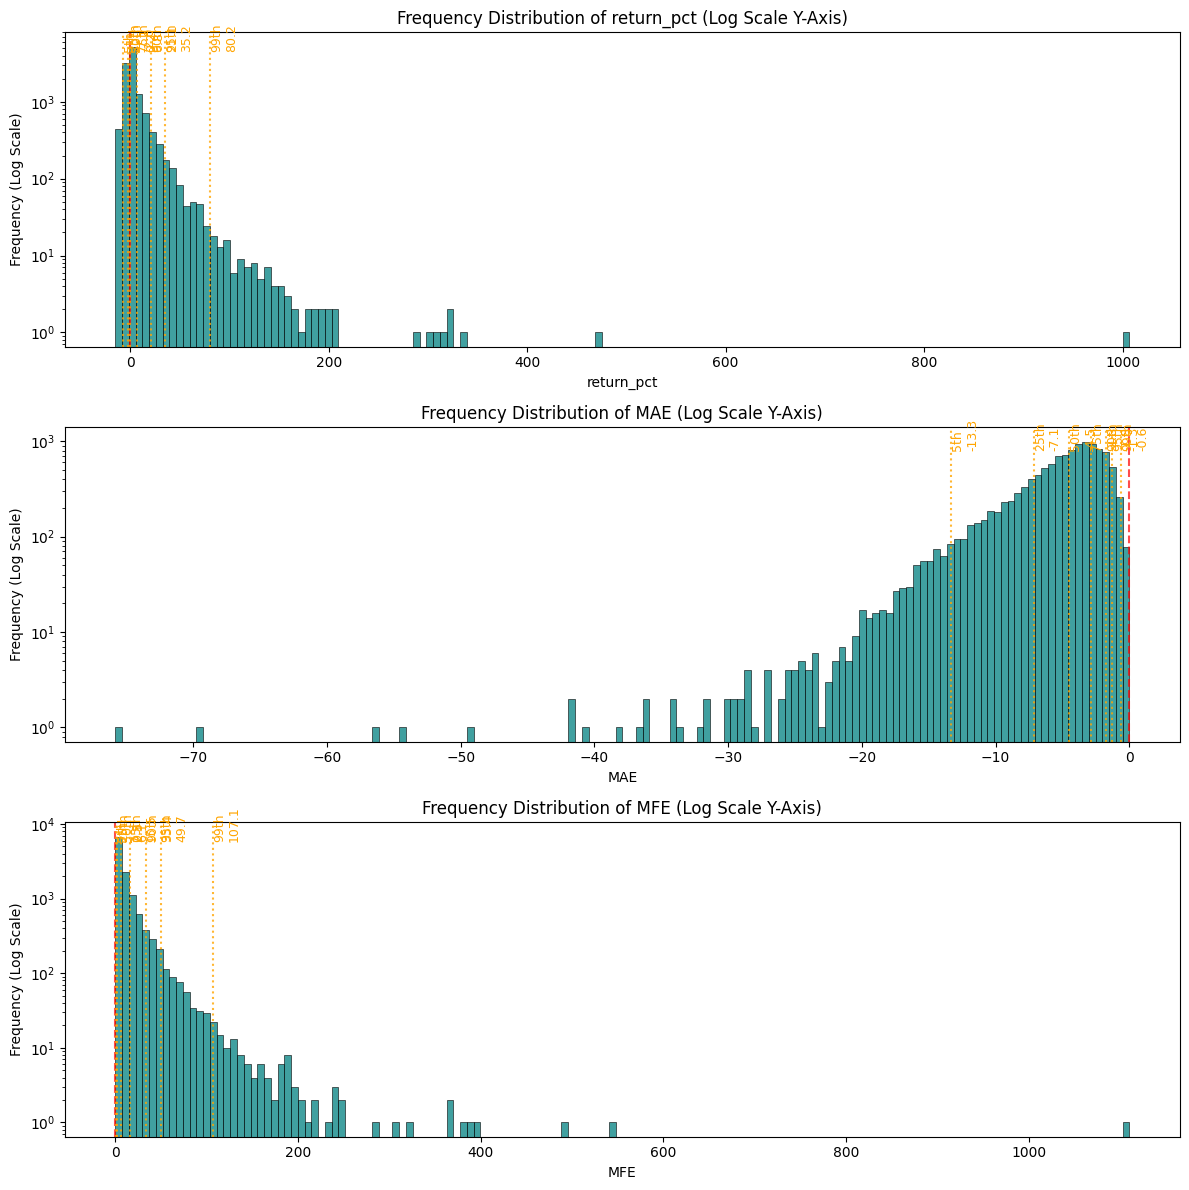

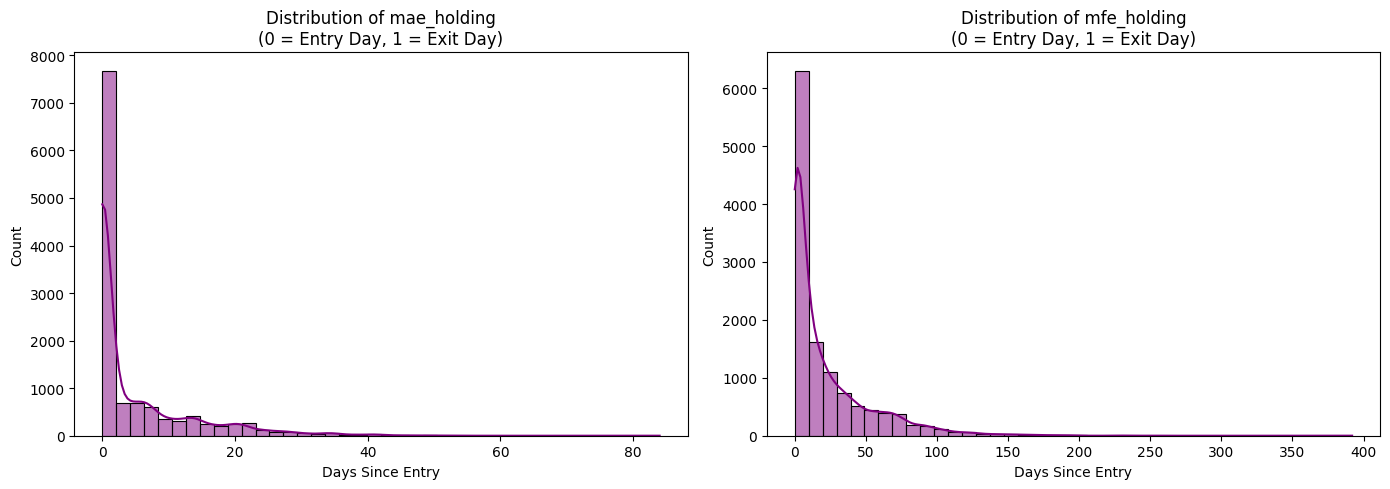

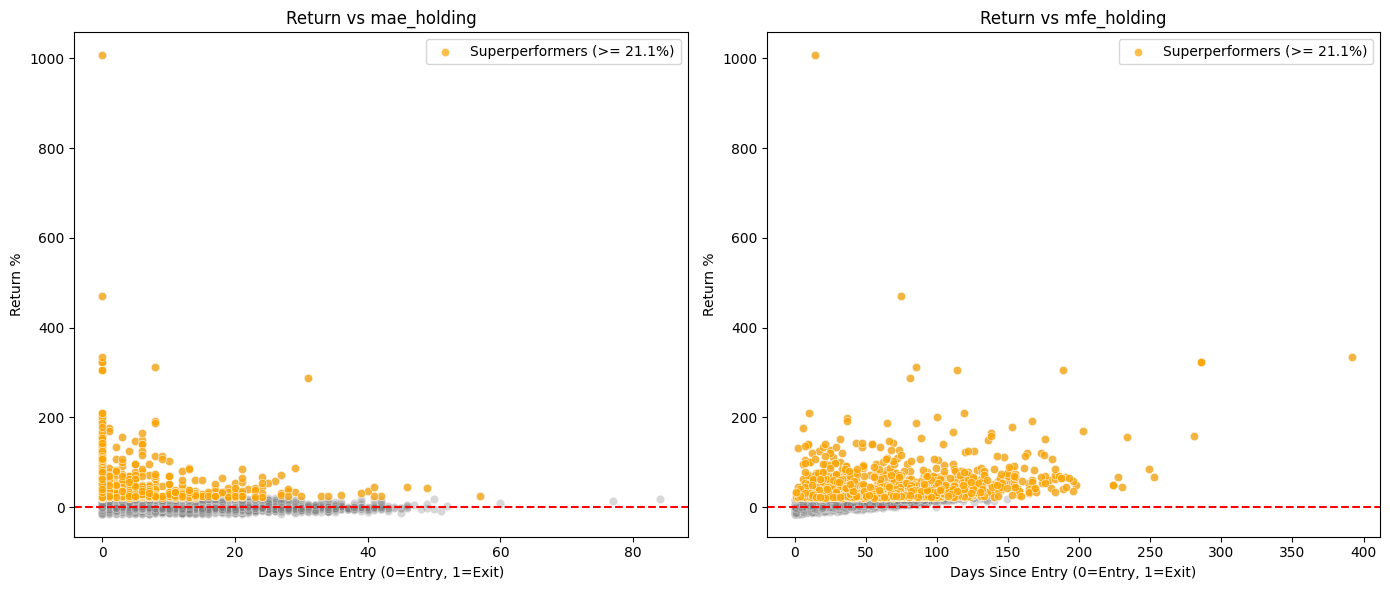


=== Thresholding Percentile Grid ===


,return_pct,MAE,MFE
1th Percentile,-11.826333,-19.103994,0.111767
5th Percentile,-7.080179,-13.306608,0.476485
10th Percentile,-4.974112,-10.702655,0.892065
25th Percentile,-1.976055,-7.142857,2.288407
50th Percentile,0.189304,-4.514187,6.136584
75th Percentile,6.752037,-2.840027,15.518962
80th Percentile,9.940006,-2.510884,19.094068
85th Percentile,14.369841,-2.141963,24.434809
90th Percentile,21.126360,-1.752974,33.417694
95th Percentile,35.166904,-1.297808,49.695325


In [13]:
# --- Advanced Target Distribution & Threshold Analysis ---

# 1. Derive Holding Period Timing Features
date_cols = ['entry_date', 'exit_date', 'mae_date', 'mfe_date']
# Ensure they are datetime
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

if 'entry_date' in df.columns and 'exit_date' in df.columns:
    # Total holding days
    df['holding_days'] = (df['exit_date'] - df['entry_date']).dt.days
    # Prevent division by zero for same-day exits
    holding_days_safe = df['holding_days'].replace(0, 1)

    if 'mae_date' in df.columns:
        df['mae_holding'] = (df['mae_date'] - df['entry_date']).dt.days # / holding_days_safe
    if 'mfe_date' in df.columns:
        df['mfe_holding'] = (df['mfe_date'] - df['entry_date']).dt.days # / holding_days_safe

target_cols = ['return_pct', 'MAE', 'MFE']
timing_cols = [c for c in ['mae_holding', 'mfe_holding'] if c in df.columns]

# --- 2. Log-Scaled Distributions (Tails & Superperformers) ---
# Using a logarithmic Y-axis prevents the peak from squashing the heavy tails
nrows = len(target_cols)
fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(12, 4 * nrows))
if nrows == 1: axes = [axes]

for i, col in enumerate(target_cols):
    if col not in df.columns: continue
        
    sns.histplot(df[col].dropna(), bins=150, kde=False, ax=axes[i], color='teal')
    axes[i].set_yscale('log') # The magic for visualizing extreme class imbalances!
    axes[i].set_title(f"Frequency Distribution of {col} (Log Scale Y-Axis)")
    axes[i].set_ylabel("Frequency (Log Scale)")
    axes[i].axvline(0, color='red', linestyle='dashed', linewidth=1.5, alpha=0.7)

    # Annotate key percentiles to help visually decide on bins
    percentiles = [5, 25, 50, 75, 90, 95, 99]
    vals = np.percentile(df[col].dropna(), percentiles)
    for p, v in zip(percentiles, vals):
        axes[i].axvline(v, color='orange', linestyle='dotted', alpha=0.8)
        axes[i].text(v, axes[i].get_ylim()[1]*0.6, f'{p}th\n{v:.1f}', rotation=90, color='orange', fontsize=9)

plt.tight_layout()
plt.show()


# --- 3. Timing of Extremes (When do MAE/MFE happen?) ---
if timing_cols:
    # 3a. Histogram of when it happens
    fig, axes = plt.subplots(1, len(timing_cols), figsize=(14, 5))
    if len(timing_cols) == 1: axes = [axes]
    
    for i, col in enumerate(timing_cols):
        sns.histplot(df[col].dropna(), bins=40, ax=axes[i], color='purple', kde=True)
        axes[i].set_title(f"Distribution of {col}\n(0 = Entry Day, 1 = Exit Day)")
        axes[i].set_xlabel(f"Days Since Entry")
        
    plt.tight_layout()
    plt.show()

    # 3b. Scatter: Timing vs Return (Where do superperformers cluster?)
    fig, axes = plt.subplots(1, len(timing_cols), figsize=(14, 6))
    if len(timing_cols) == 1: axes = [axes]
    
    for i, col in enumerate(timing_cols):
        sns.scatterplot(x=df[col], y=df['return_pct'], alpha=0.3, ax=axes[i], color='gray')
        
        # Highlight top 10% superperformers
        p90 = df['return_pct'].quantile(0.90)
        superperformers = df[df['return_pct'] >= p90]
        sns.scatterplot(x=superperformers[col], y=superperformers['return_pct'], 
                        color='orange', label=f'Superperformers (>= {p90:.1f}%)', alpha=0.7, ax=axes[i])
        
        axes[i].set_title(f"Return vs {col}")
        axes[i].set_xlabel(f"Days Since Entry (0=Entry, 1=Exit)")
        axes[i].set_ylabel("Return %")
        axes[i].axhline(0, color='red', linestyle='dashed')
        axes[i].legend()

    plt.tight_layout()
    plt.show()


# --- 4. Percentile Grid for Thresholding ---
print("\n=== Thresholding Percentile Grid ===")
percentiles_to_check = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.8, 0.85, 0.9, 0.95, 0.98, 0.99]
percentile_df = df[target_cols].quantile(percentiles_to_check)
percentile_df.index = [f"{int(p*100)}th Percentile" for p in percentiles_to_check]
display(percentile_df)


=== Class Distribution ===
Class 0: 2712 rows (22.2%)
Class 1: 5114 rows (41.8%)
Class 2: 2991 rows (24.5%)
Class 3: 1416 rows (11.6%)


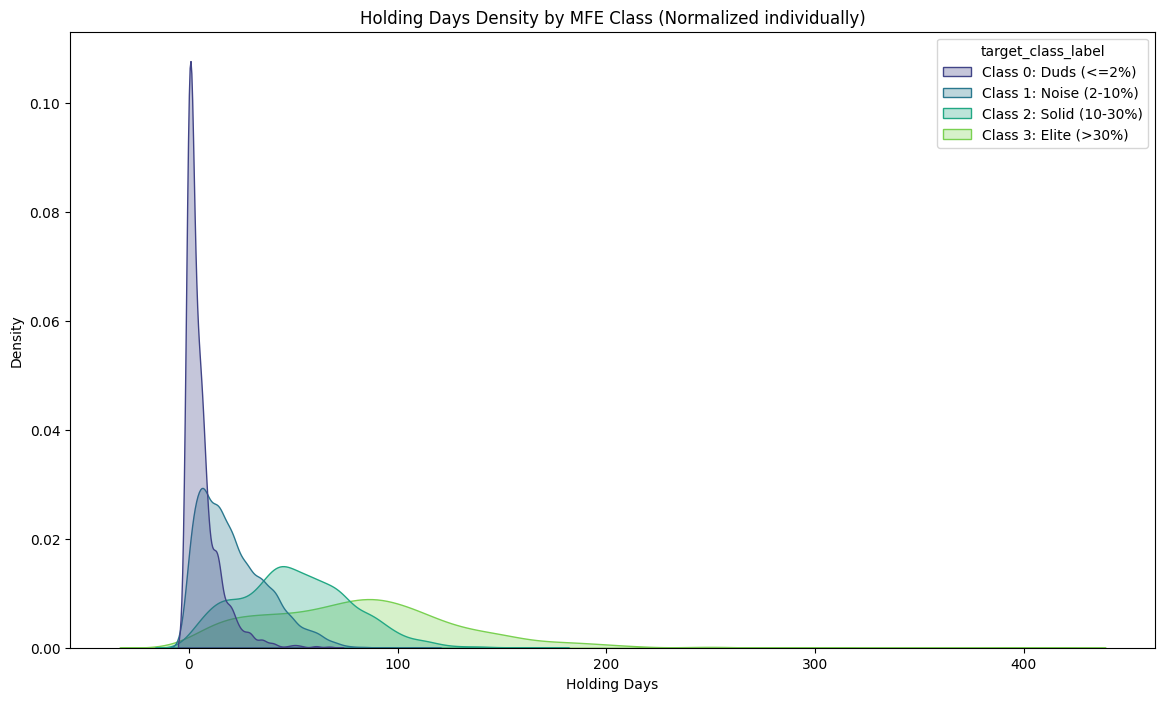

In [14]:
# --- Create MFE Bins ---

# Define our MFE Bin edges
conditions = [
    (df['MFE'] <= 2.0),
    (df['MFE'] > 2.0) & (df['MFE'] <= 10.0),
    (df['MFE'] > 10.0) & (df['MFE'] <= 30.0),
    (df['MFE'] > 30.0)
]
choices = [0, 1, 2, 3]

# Create the target column
df['target_class'] = np.select(conditions, choices, default=np.nan)

# Drop any rows where MFE might have been missing
df = df.dropna(subset=['target_class'])
df['target_class'] = df['target_class'].astype(int)

# Check the class balance
class_counts = df['target_class'].value_counts().sort_index()
class_pcts = df['target_class'].value_counts(normalize=True).sort_index() * 100

print("=== Class Distribution ===")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count} rows ({class_pcts[cls]:.1f}%)")

choices = ['Class 0: Duds (<=2%)', 'Class 1: Noise (2-10%)', 'Class 2: Solid (10-30%)', 'Class 3: Elite (>30%)']

# Fill NA MFE with a dummy string
df['target_class_label'] = np.select(conditions, choices, default='Unknown')

# Drop NA rows
df = df[df['target_class_label'] != 'Unknown']

plt.figure(figsize=(14, 8))
sns.kdeplot(
    data=df, 
    x='holding_days', 
    hue='target_class_label',
    hue_order=choices,
    common_norm=False, 
    fill=True, 
    palette='viridis',
    alpha=0.3
)
plt.title('Holding Days Density by MFE Class (Normalized individually)')
plt.xlabel('Holding Days')
plt.ylabel('Density')
plt.show()

In [24]:
df_clean = df[available_features + ['MFE']].copy()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Hang\AppData\Local\Temp\ipykernel_56488\123227895.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Hang\AppData\Local\Temp\ipykernel_56488\123227895.py:48: FutureWarning: 

Passing 

Preparing Multiclass EDA Distributions...


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Hang\AppData\Local\Temp\ipykernel_56488\123227895.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Hang\AppData\Local\Temp\ipykernel_56488\123227895.py:48: FutureWarning: 

Passing 

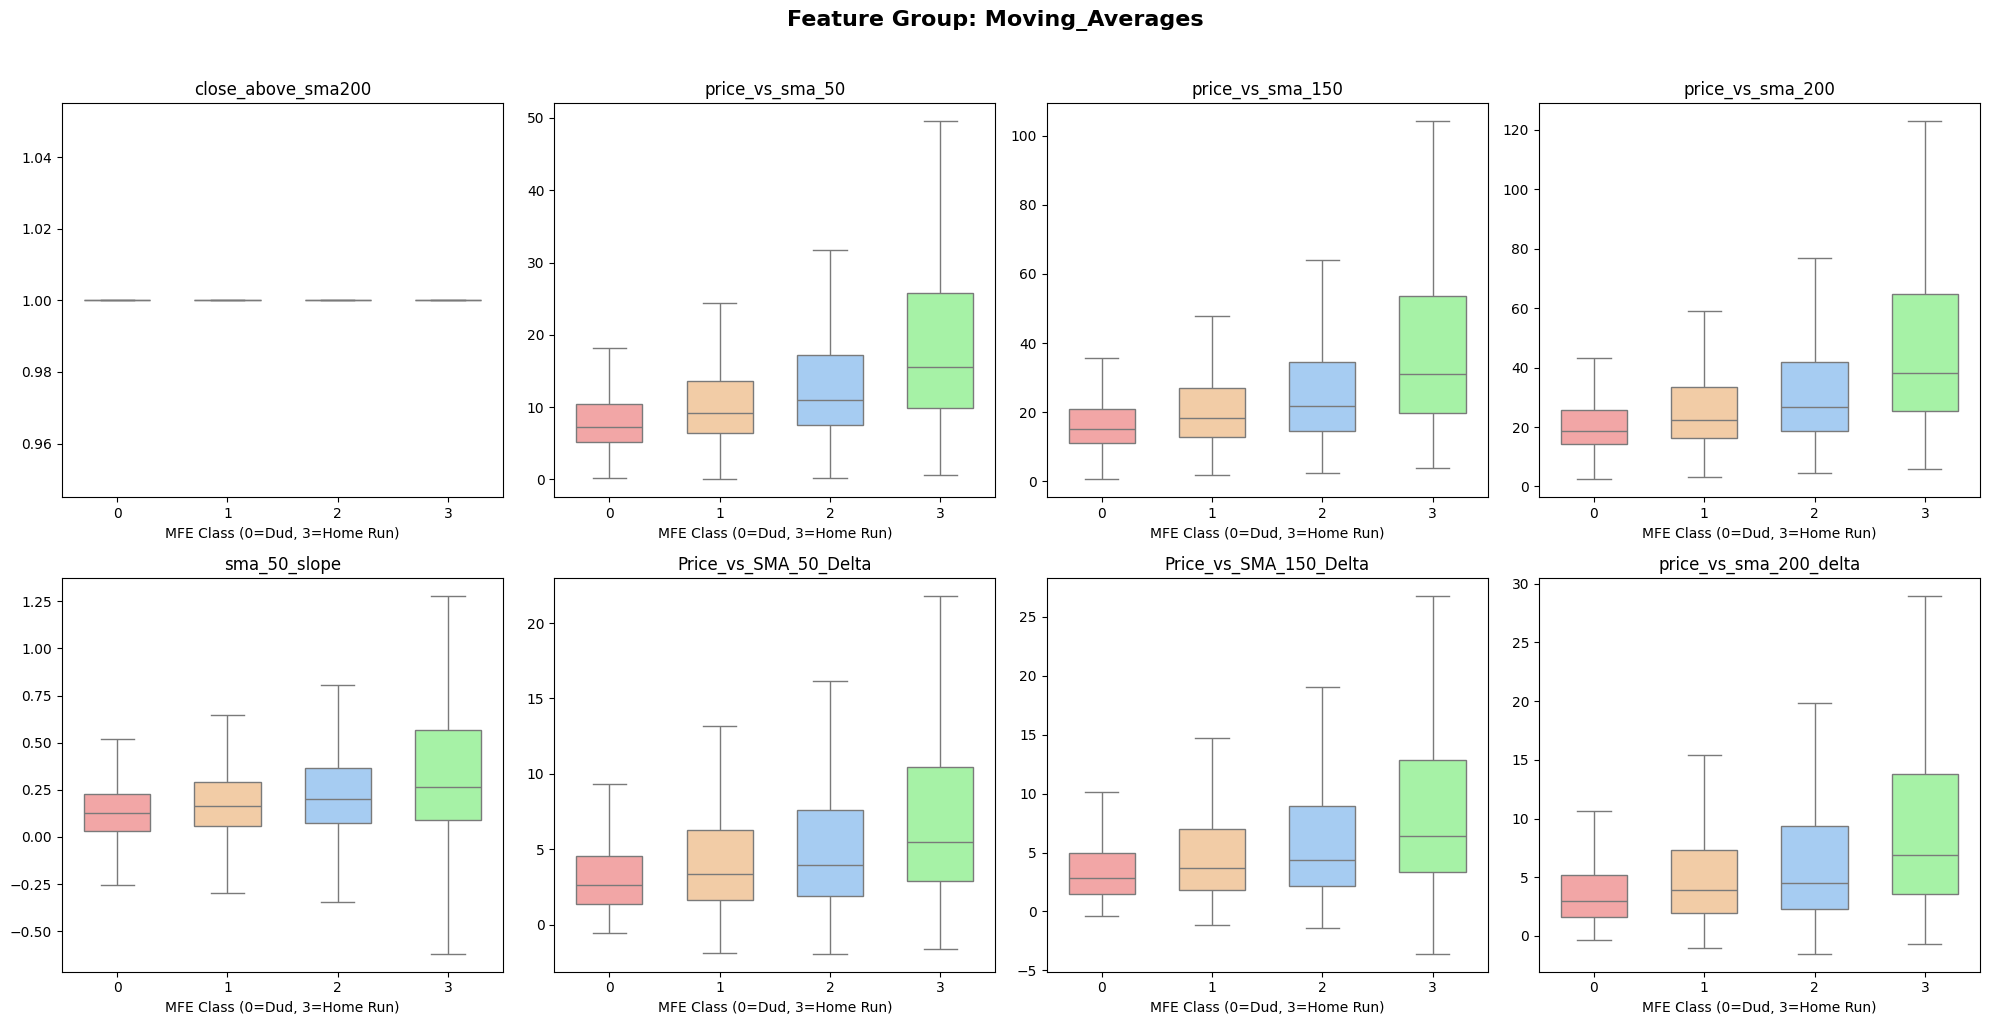

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Hang\AppData\Local\Temp\ipykernel_56488\123227895.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Hang\AppData\Local\Temp\ipykernel_56488\123227895.py:48: FutureWarning: 

Passing 

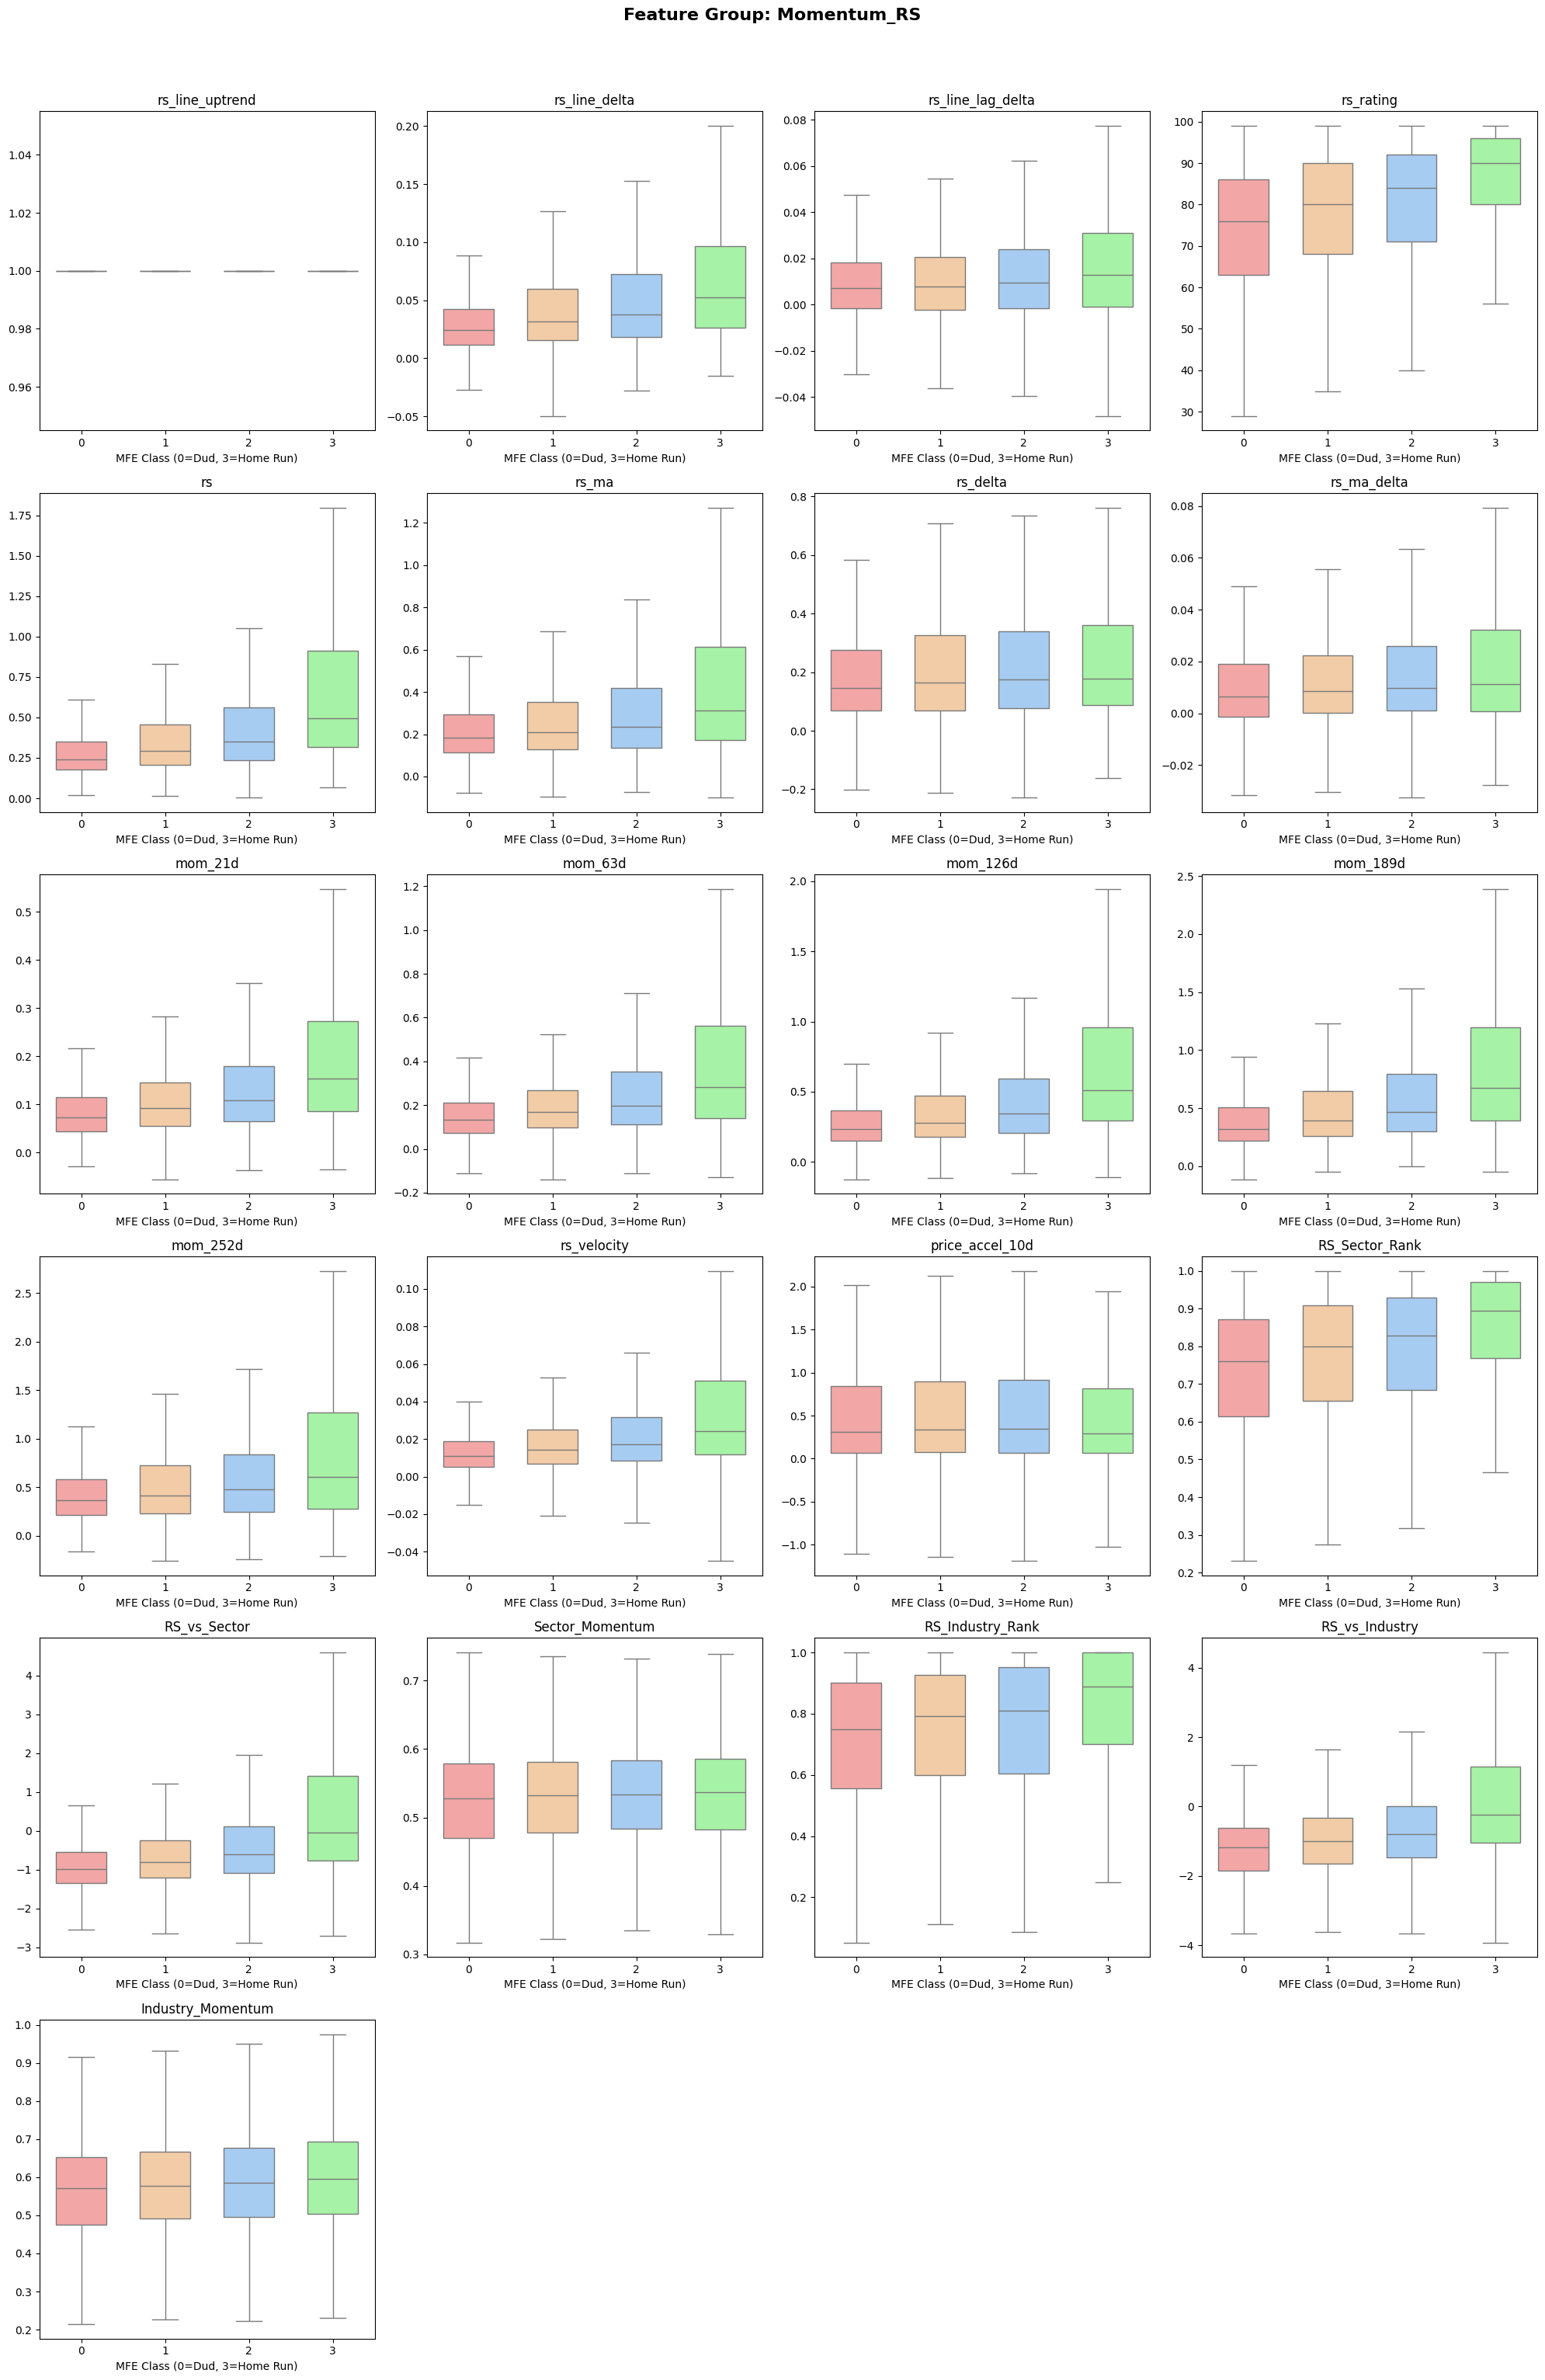

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Hang\AppData\Local\Temp\ipykernel_56488\123227895.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Hang\AppData\Local\Temp\ipykernel_56488\123227895.py:48: FutureWarning: 

Passing 

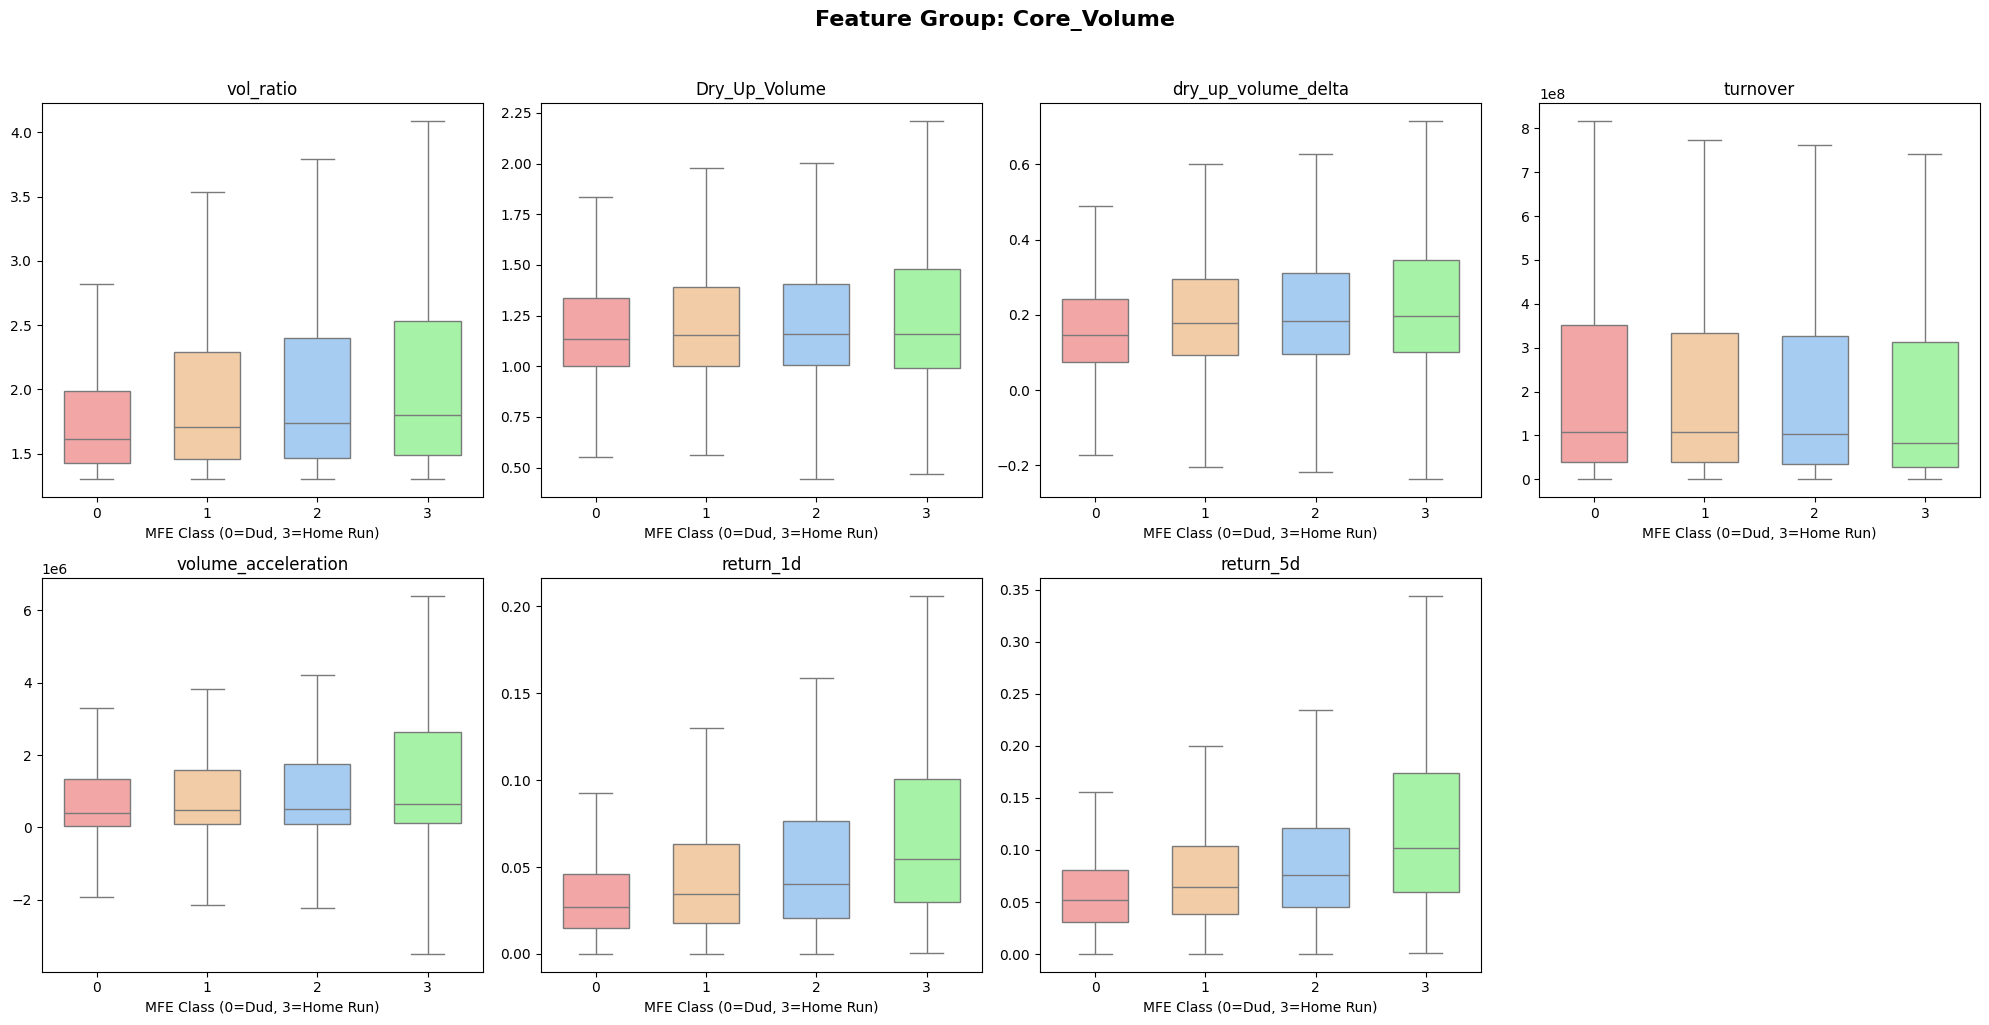

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Hang\AppData\Local\Temp\ipykernel_56488\123227895.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Hang\AppData\Local\Temp\ipykernel_56488\123227895.py:48: FutureWarning: 

Passing 

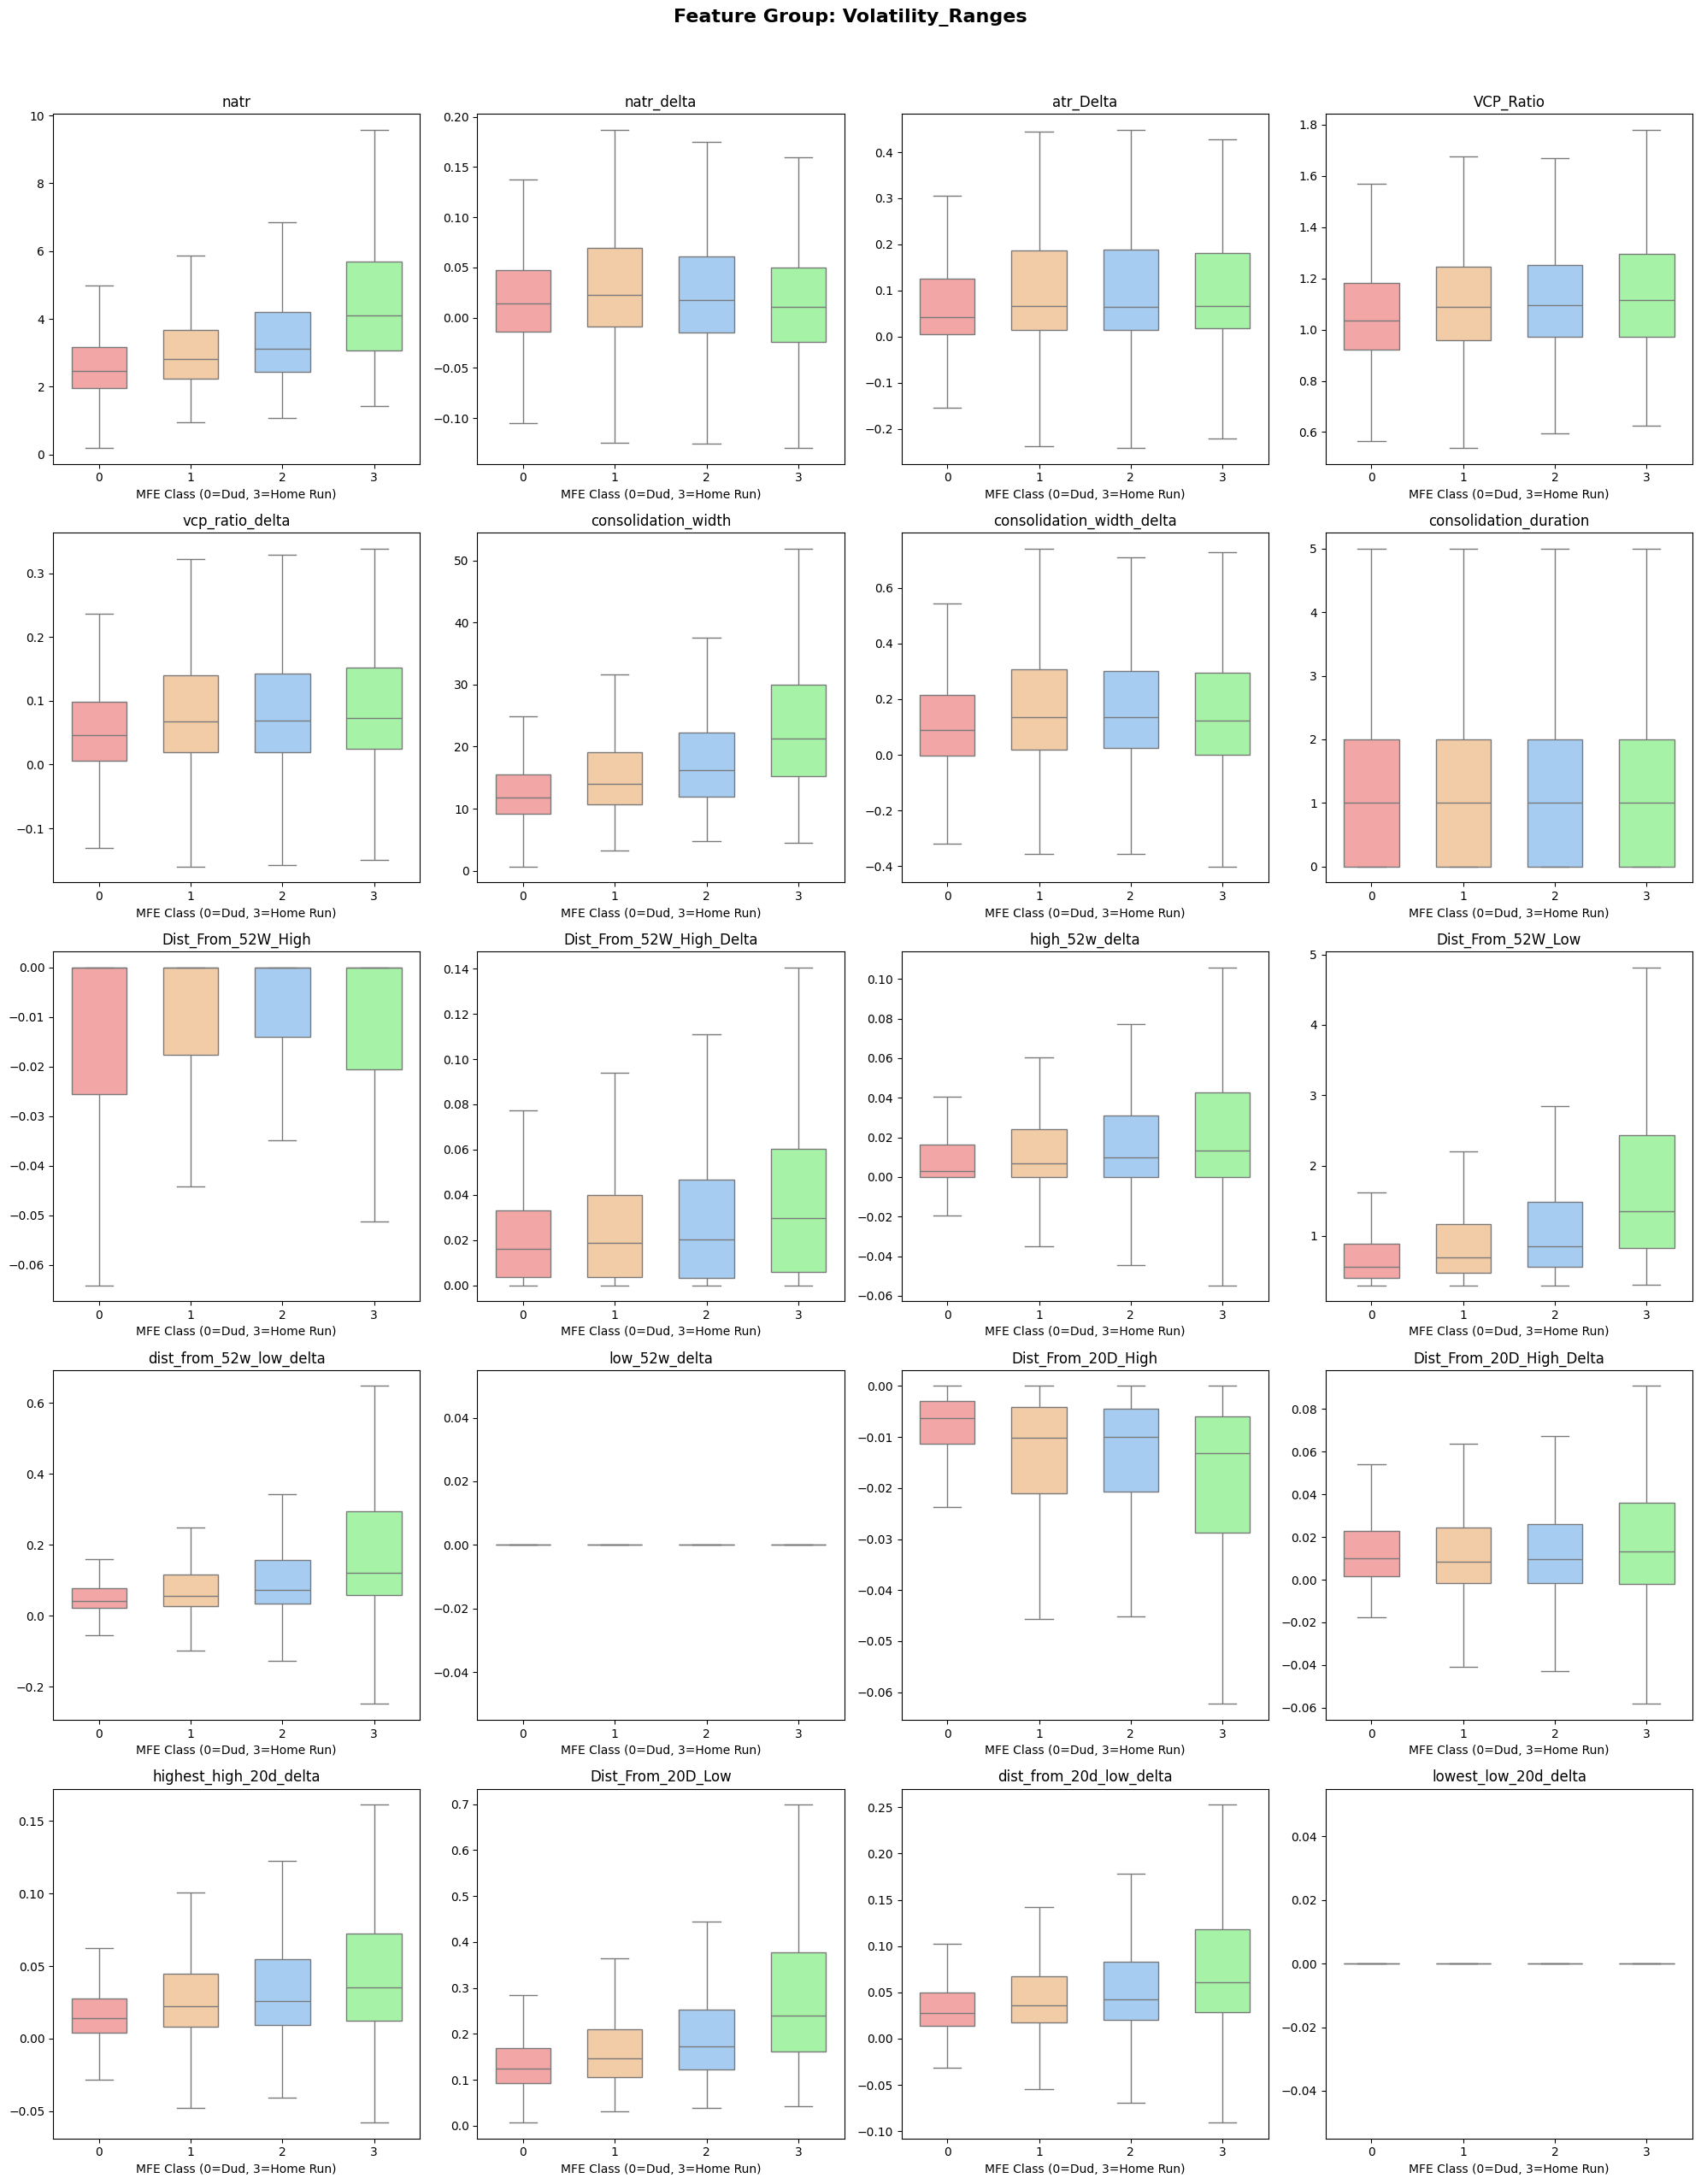

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Hang\AppData\Local\Temp\ipykernel_56488\123227895.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Hang\AppData\Local\Temp\ipykernel_56488\123227895.py:48: FutureWarning: 

Passing 

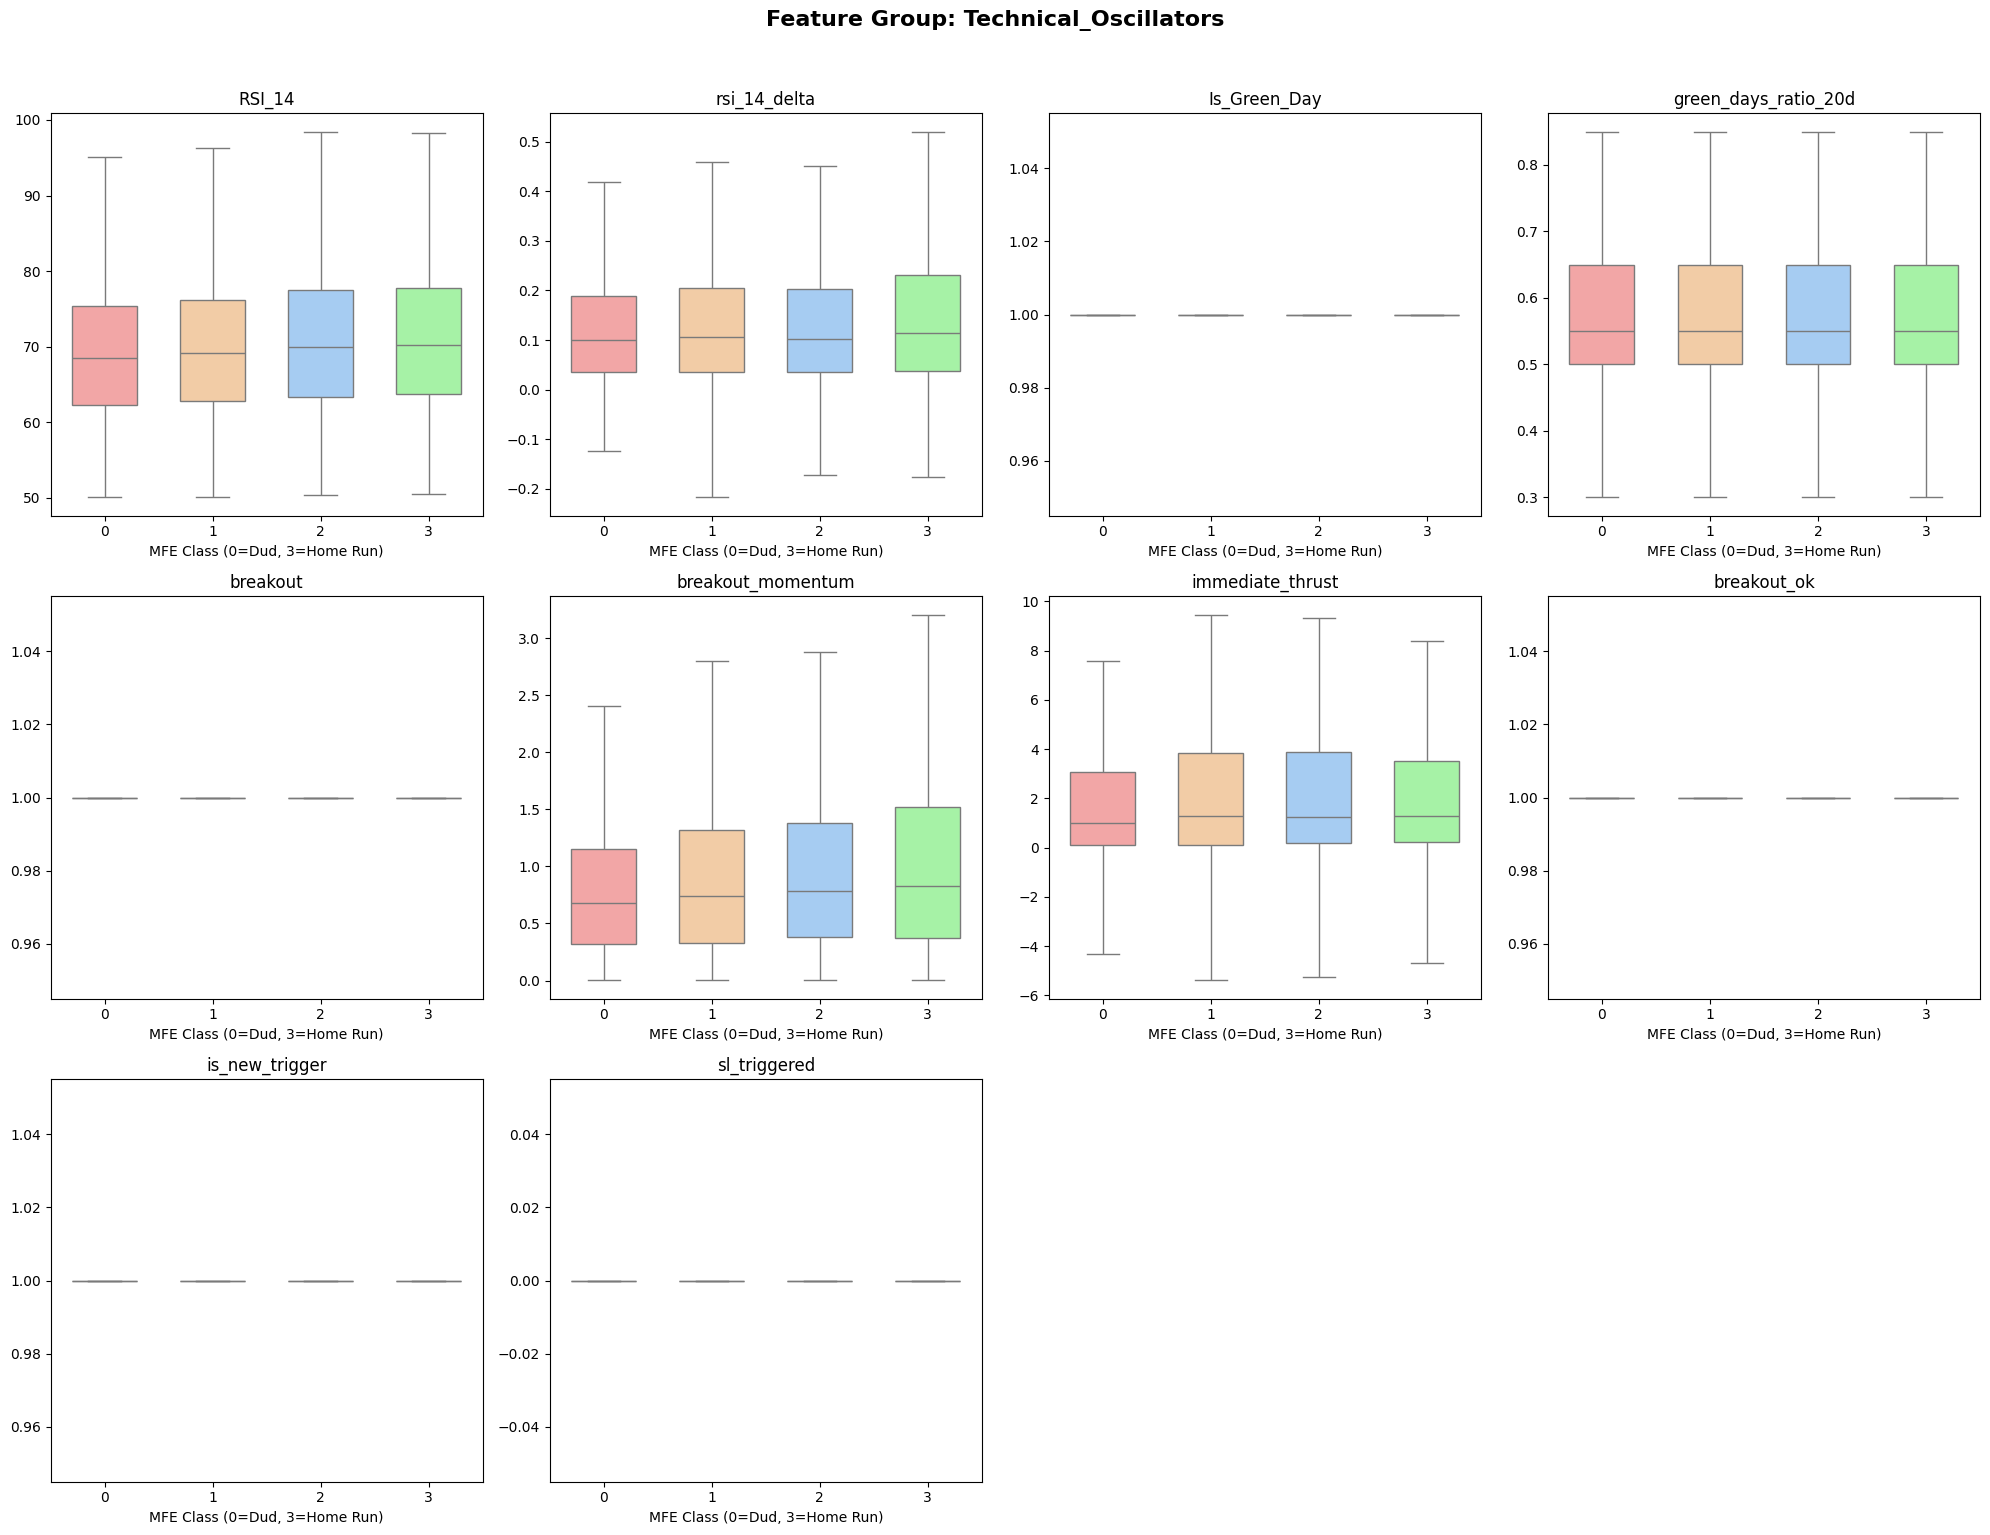

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Hang\AppData\Local\Temp\ipykernel_56488\123227895.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Hang\AppData\Local\Temp\ipykernel_56488\123227895.py:48: FutureWarning: 

Passing 

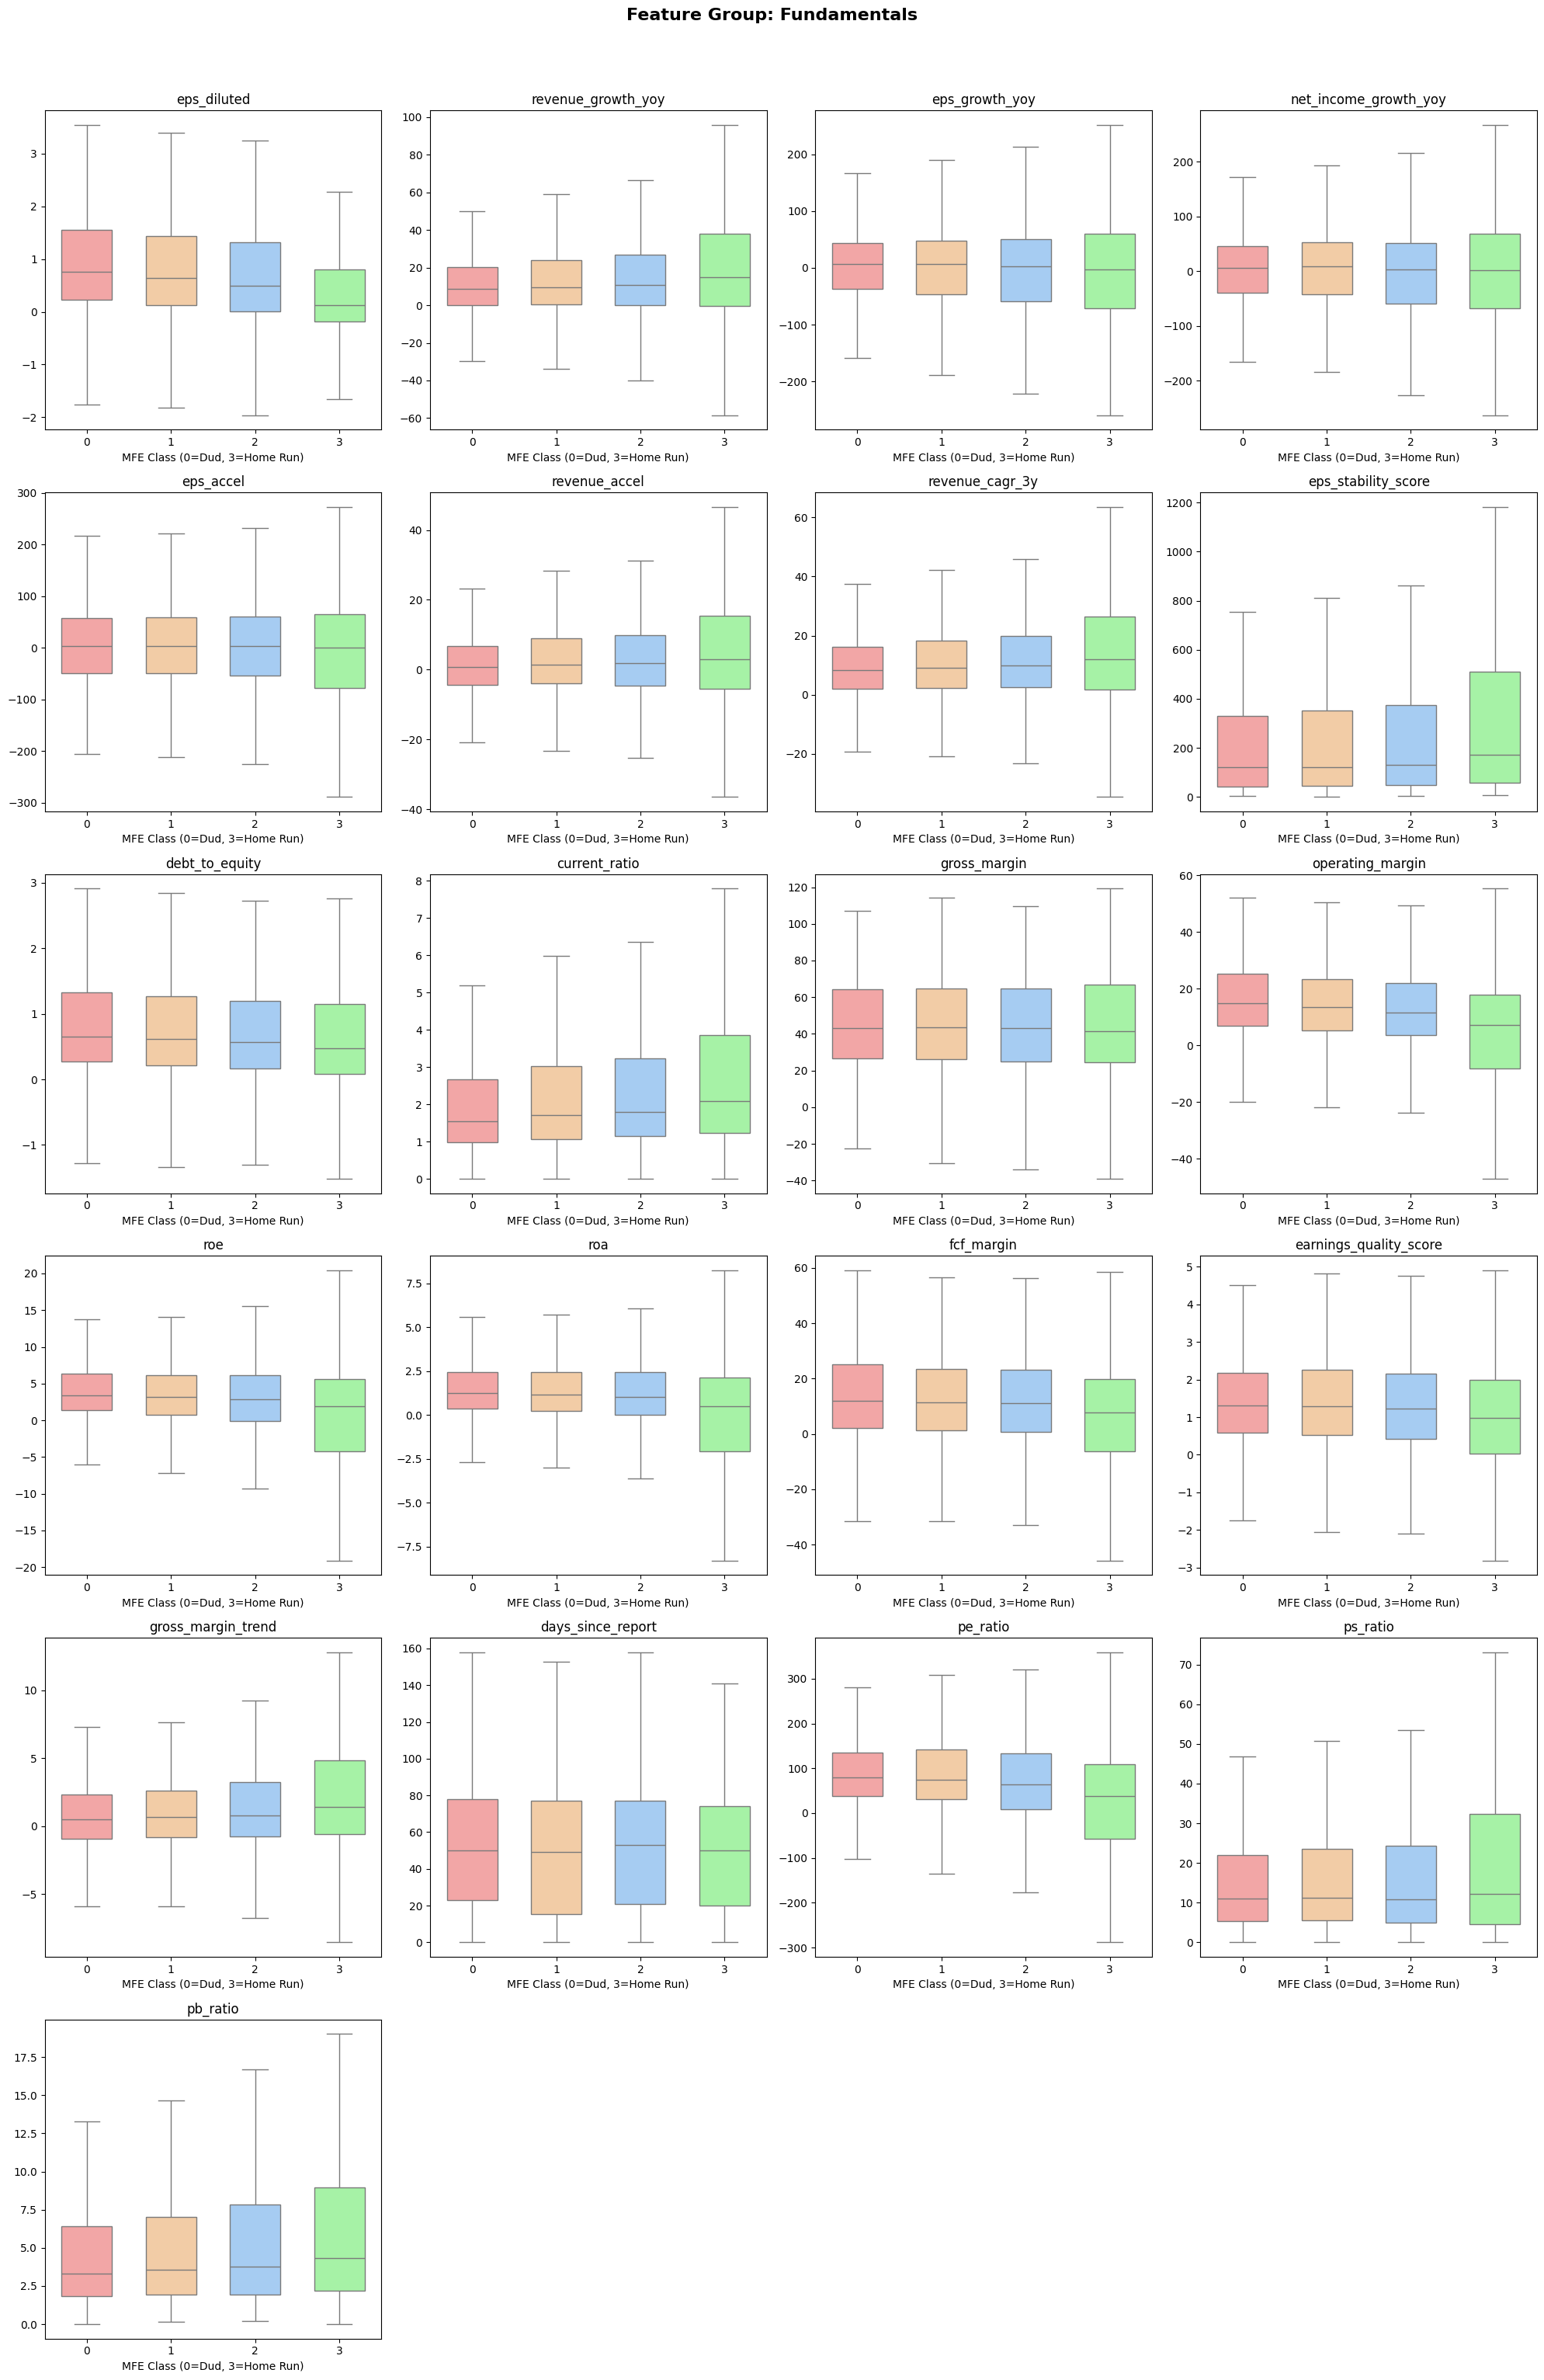

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Hang\AppData\Local\Temp\ipykernel_56488\123227895.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Hang\AppData\Local\Temp\ipykernel_56488\123227895.py:48: FutureWarning: 

Passing 

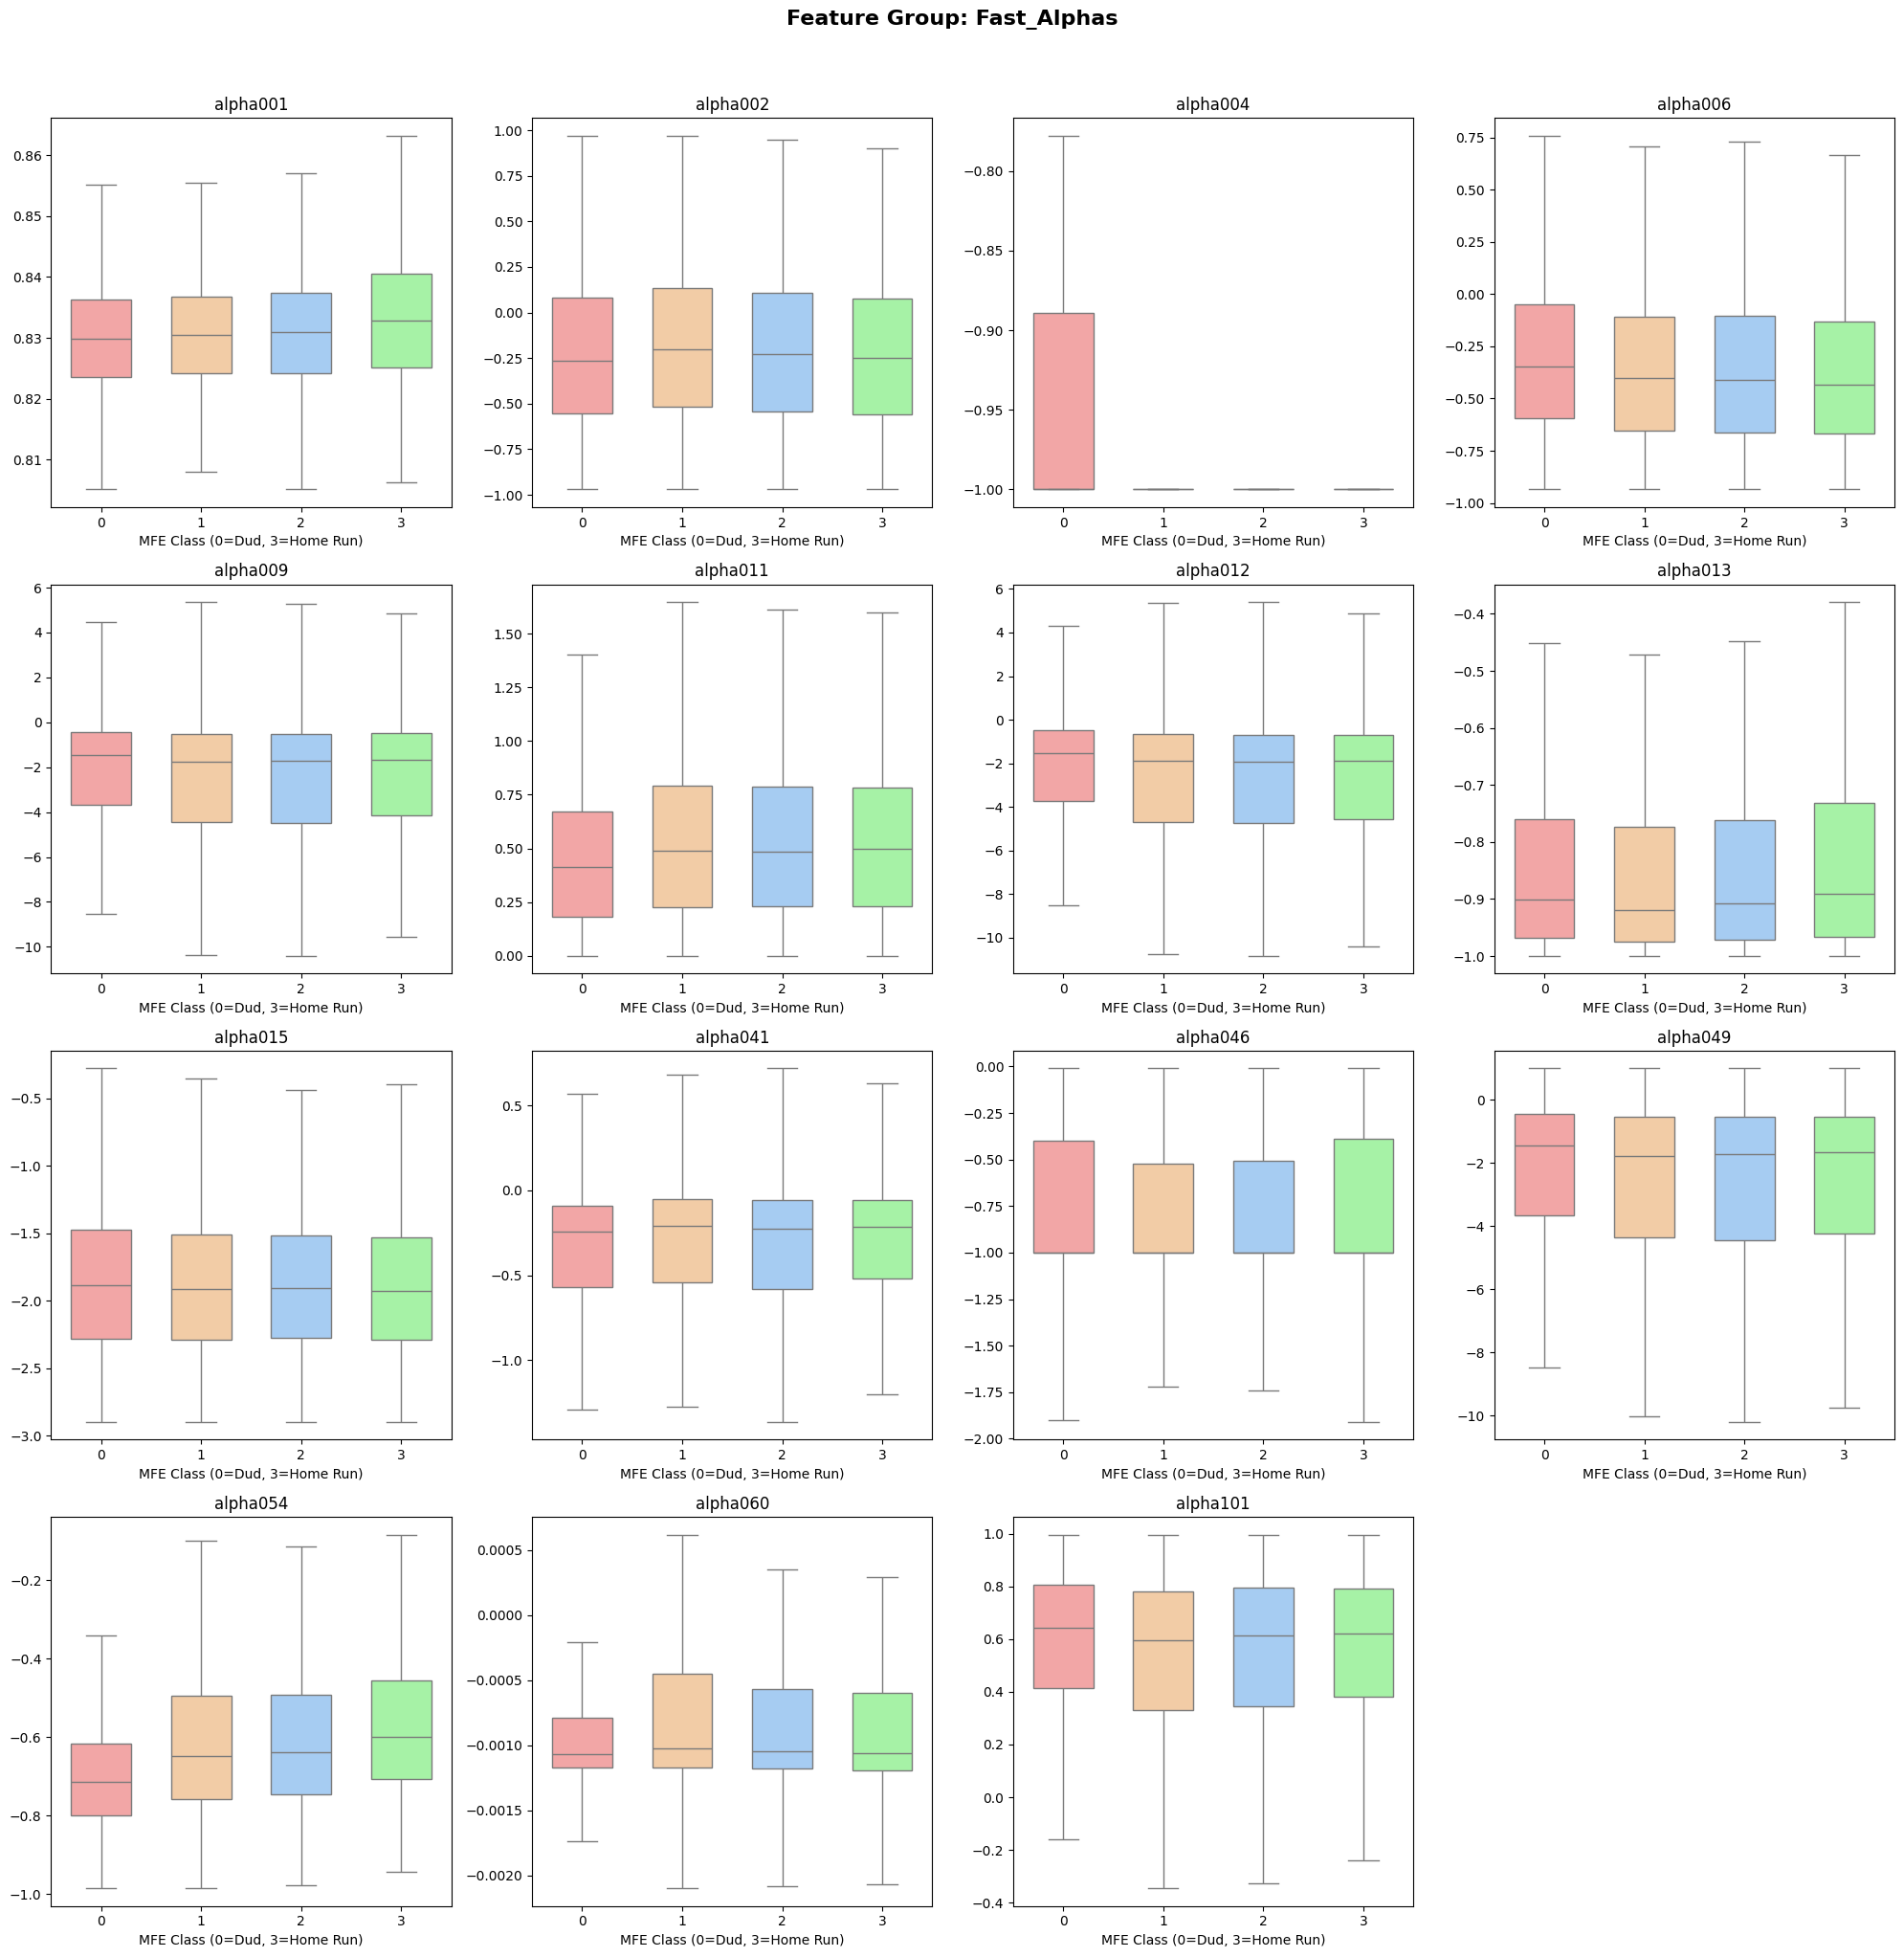

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Hang\AppData\Local\Temp\ipykernel_56488\123227895.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Hang\AppData\Local\Temp\ipykernel_56488\123227895.py:48: FutureWarning: 

Passing 

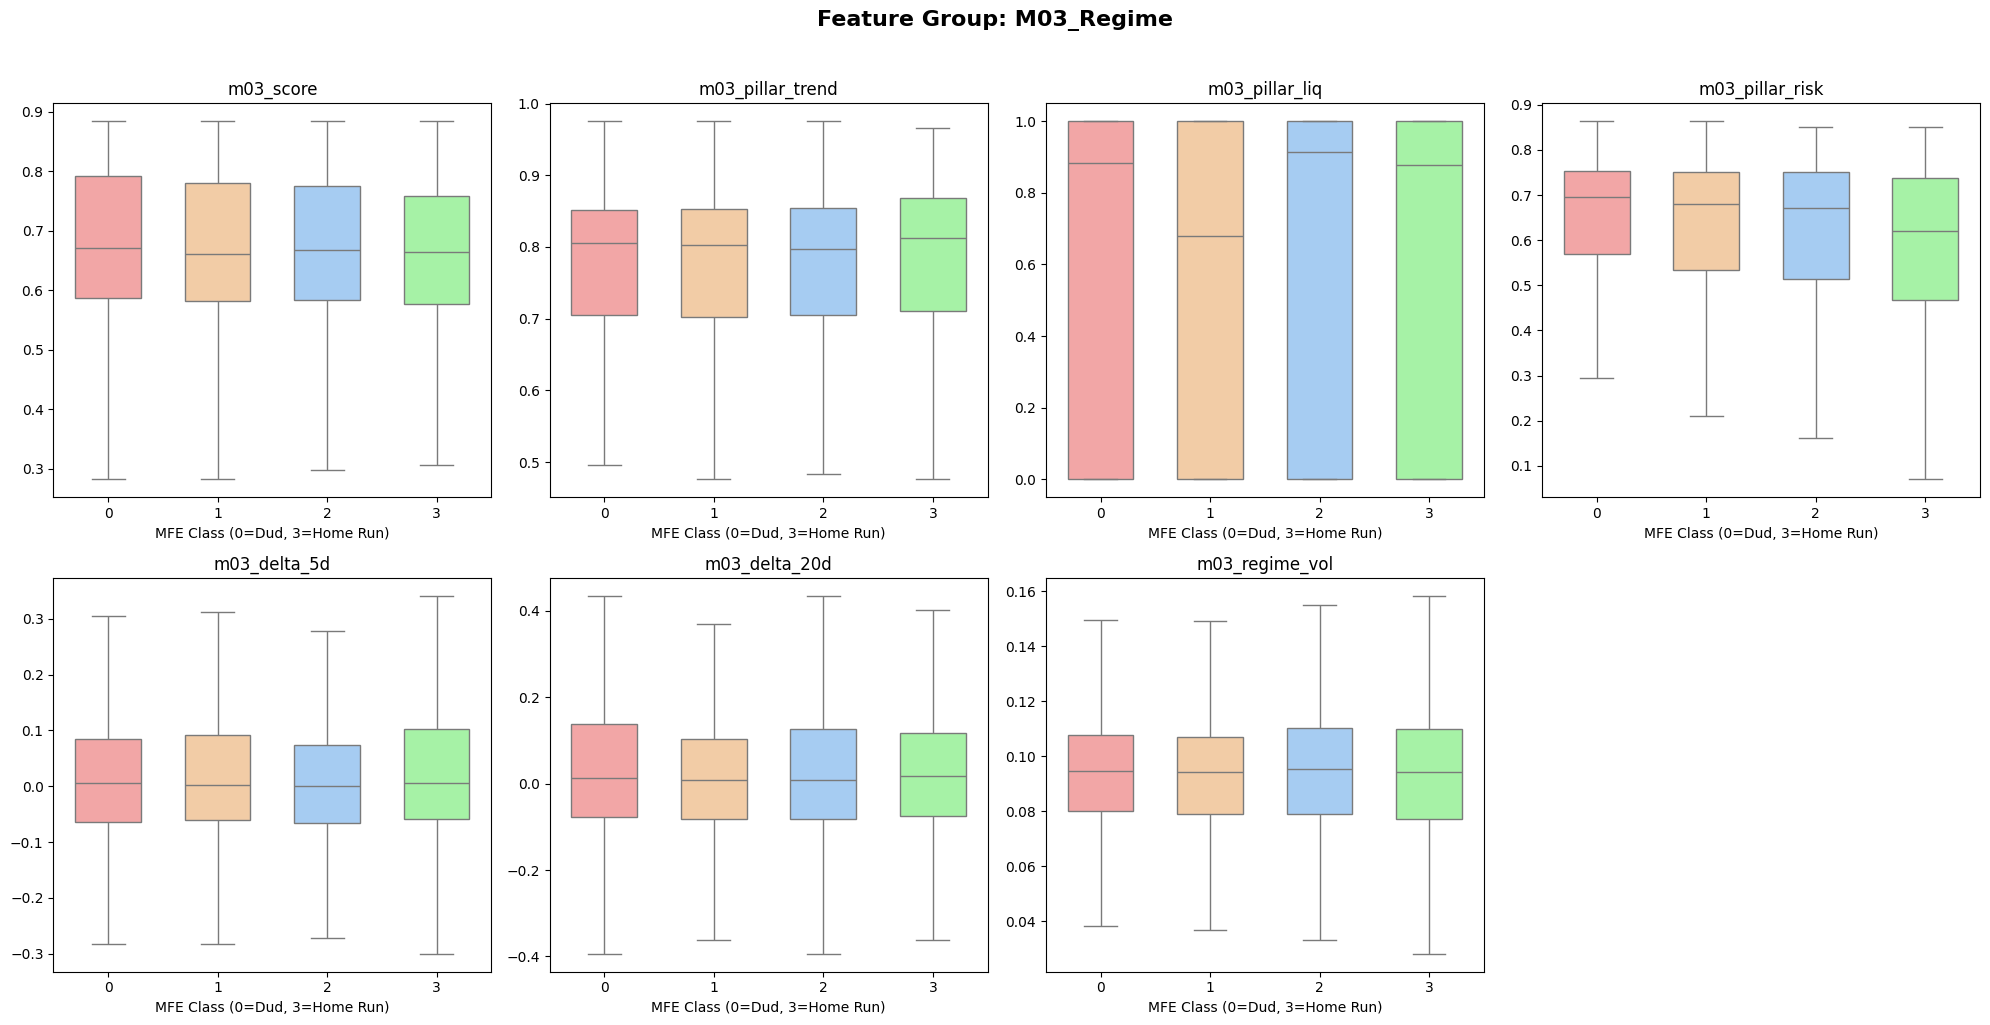

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

print("Preparing Multiclass EDA Distributions...")

# 1. Define the Target Classes (using your 4-bin MFE logic)
# Note: Adjust 'mfe_pct' to match your exact MFE column name if different
mfe_col = 'mfe_pct' if 'mfe_pct' in df_clean.columns else 'MFE'

conditions = [
    (df_clean[mfe_col] <= 2.0),
    (df_clean[mfe_col] > 2.0) & (df_clean[mfe_col] <= 10.0),
    (df_clean[mfe_col] > 10.0) & (df_clean[mfe_col] <= 30.0),
    (df_clean[mfe_col] > 30.0)
]
# Classes: 0=Noise, 1=Moderate, 2=Strong, 3=Home Run
choices = [0, 1, 2, 3]
df_clean['target_class'] = np.select(conditions, choices, default=0)

# 2. Custom color palette (Cold/Red to Hot/Green)
palette = {'0': '#ff9999', '1': '#ffcc99', '2': '#99ccff', '3': '#99ff99'}

# 3. Plotting Loop over FEATURE_GROUPS
for group_name, features in FEATURE_GROUPS.items():
    # Only plot features that successfully survived the master drop list
    valid_features = [f for f in features if f in df_clean.columns]
    
    if not valid_features:
        continue
        
    num_features = len(valid_features)
    cols = 4
    rows = math.ceil(num_features / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    fig.suptitle(f'Feature Group: {group_name}', fontsize=16, fontweight='bold', y=1.02)
    
    # Flatten axes for easy iteration, handling the single-row edge case
    axes = axes.flatten() if num_features > 1 else [axes]
    
    for i, feature in enumerate(valid_features):
        ax = axes[i]
        
        # Boxplot with hidden fliers to keep the y-axis readable
        sns.boxplot(
            data=df_clean, x='target_class', y=feature, 
            ax=ax, palette=palette, showfliers=False, width=0.6
        )
        
        ax.set_title(feature, fontsize=12)
        ax.set_xlabel('MFE Class (0=Dud, 3=Home Run)')
        ax.set_ylabel('')
        
    # Hide any unused subplots in the grid
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

## Feature Dictionary & Tooling

In [59]:
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

# --- Centralized Master Feature Dictionary ---
FEATURE_GROUPS = {
    "Moving_Averages": [
        'close_above_sma200', 'price_vs_sma_50', 'price_vs_sma_150', 'price_vs_sma_200', 
        'sma_50_slope', 'Price_vs_SMA_50_Delta', 'Price_vs_SMA_150_Delta', 'price_vs_sma_200_delta'
    ],
    "Momentum_RS": [
        'rs_line_uptrend', 'rs_line_delta', 'rs_line_lag_delta', 'rs_rating', 'rs', 'rs_ma', 
        'rs_delta', 'rs_ma_delta', 'mom_21d', 'mom_63d', 'mom_126d', 'mom_189d', 'mom_252d', 
        'rs_velocity', 'price_accel_10d', 'RS_Sector_Rank', 'RS_vs_Sector', 'Sector_Momentum', 
        'RS_Industry_Rank', 'RS_vs_Industry', 'Industry_Momentum'
    ],
    "Core_Volume": [
        'vol_ratio', 'Dry_Up_Volume', 'dry_up_volume_delta', 'turnover', 
        'volume_acceleration', 'return_1d', 'return_5d'
    ],
    "Volatility_Ranges": [
        'natr', 'natr_delta', 'atr_Delta', 'VCP_Ratio', 'vcp_ratio_delta', 
        'consolidation_width', 'consolidation_width_delta', 'consolidation_duration', 
        'Dist_From_52W_High', 'Dist_From_52W_High_Delta',
        'Dist_From_52W_Low', 
        'dist_from_52w_low_delta', 
        'low_52w_delta', 'high_52w_delta',
        'Dist_From_20D_High', 'Dist_From_20D_High_Delta', 'highest_high_20d_delta',
        'Dist_From_20D_Low', 'dist_from_20d_low_delta', 'lowest_low_20d_delta'
    ],
    "Technical_Oscillators": [
        'RSI_14', 'rsi_14_delta', 'Is_Green_Day', 'green_days_ratio_20d', 'breakout', 
        'breakout_momentum', 'immediate_thrust', 
        # 'breakout_ok', 'is_new_trigger', 'sl_triggered'
    ],
    "Fundamentals": [
        'eps_diluted', 'revenue_growth_yoy', 'eps_growth_yoy', 'net_income_growth_yoy', 
        'eps_accel', 'revenue_accel', 'revenue_cagr_3y', 'eps_stability_score', 
        'debt_to_equity', 'current_ratio', 'gross_margin', 'operating_margin', 'roe', 'roa', 
        'fcf_margin', 'earnings_quality_score', 'gross_margin_trend', 'days_since_report', 
        'pe_ratio', 'ps_ratio', 'pb_ratio'
    ],
    "Fast_Alphas": [
        'alpha001', 'alpha002', 'alpha004', 'alpha006', 'alpha009', 'alpha011', 'alpha012', 
        'alpha013', 'alpha015', 'alpha041', 'alpha046', 'alpha049', 'alpha054', 'alpha060', 
        'alpha101'
    ],
    "M03_Regime": [
        'm03_score', 'm03_pillar_trend', 'm03_pillar_liq', 'm03_pillar_risk', 
        'm03_delta_5d', 'm03_delta_20d', 'm03_regime_vol'
    ]
}

# Quick validation check to ensure no features were left behind
total_grouped = sum(len(features) for features in FEATURE_GROUPS.values())
print(f"Total features mapped: {total_grouped} / 109")

Total features mapped: 106 / 109


In [68]:
# --- Modular Training & Plotting Function ---
def train_and_evaluate_xgboost(raw_df, active_groups, exclude_features=None, target_col='target_class', title_prefix="Model", show_plots=True):
    """
    Trains an XGBoost multiclass model using only features from the specified groups.
    Automatically handles explicit target leakage prevention and chronological splitting.
    """
    print(f"\n{'='*50}\n=== Starting Run: {title_prefix} ===\n{'='*50}")
    
    # 1. Standardize exclusions
    exclude_features = [f.lower() for f in exclude_features] if exclude_features else []
    
    # 2. Build whitelist from chosen groups
    active_whitelist = []
    for group in active_groups:
        active_whitelist.extend([f.lower() for f in FEATURE_GROUPS.get(group, [])])
        
    # 3. Prevent Data Leakage (Explicit Drop)
    explicit_drop_cols = [
        'entry_date', 'exit_date', 'return_pct', 'target', 'days_held', 'return_at_exit',
        'holding_days', 'MAE', 'days_observed', 'MFE', 'exit_price', 'entry_price', 
        'mae_date', 'mfe_date', 'mae_holding', 'mfe_holding', 'ticker', 'close', target_col,
        'trade_id', 'feature_version', 'is_elite'
    ]
    
    # 4. Filter features safely
    candidate_features = [
         c for c in raw_df.columns 
         if c.lower() in active_whitelist 
         and c.lower() not in explicit_drop_cols 
         and c.lower() not in exclude_features
         and pd.api.types.is_numeric_dtype(raw_df[c])
    ]
    
    print(f"-> Active Feature Groups ({len(active_groups)}): {active_groups}")
    if exclude_features:
        print(f"-> Explicitly Excluded ({len(exclude_features)}): {exclude_features}")
    print(f"-> Final Feature Count Fed to XGBoost: {len(candidate_features)}\n")
    
    # 5. Prepare Data
    df_clean = raw_df.dropna(subset=[target_col]).copy()
    X = df_clean[candidate_features].replace([np.inf, -np.inf], np.nan) 
    y = df_clean[target_col]
    
    # 6. Chronological Train/Test Split
    if 'entry_date' in df_clean.columns:
        df_clean = df_clean.sort_values('entry_date')
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    print(f"Training on {len(X_train)} train samples (Testing on {len(X_test)})...")
    
    # 7. Class weights
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    sample_weights = y_train.map(dict(zip(classes, weights)))
    
    # 8. Train
    model = xgb.XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, objective='multi:softprob',
        num_class=len(classes), random_state=42, n_jobs=-1
    )
    model.fit(X_train, y_train, sample_weight=sample_weights)
    
    # 9. Evaluate & Report
    preds = model.predict(X_test)
    print("\n--- Classification Report (Out-of-Sample) ---")
    print(classification_report(y_test, preds))
    
    # 10. SHAP Generation
    print("\nCalculating SHAP values...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    
    # Target Class 3 (Superperformers) extraction handling varying shap version array shapes
    shap_values_elite = shap_values[3] if isinstance(shap_values, list) else shap_values[:, :, 3]
    
    if show_plots:
        # Global Bar Plot
        plt.figure(figsize=(10, 6))
        plt.title(f"{title_prefix}\nTop Features Driving Elite Superperformers")
        shap.summary_plot(shap_values_elite, X_test, plot_type="bar", max_display=15, show=False)
        plt.tight_layout()
        plt.show()

        # Directional Dot Plot
        plt.figure(figsize=(10, 6))
        plt.title(f"{title_prefix}\nDirectional Impact on Elite Probability")
        shap.summary_plot(shap_values_elite, X_test, plot_type="dot", max_display=15, show=False)
        plt.tight_layout()
        plt.show()
    
    return model, explainer, candidate_features


## Model Iteration and Testing

In [71]:
df['return_adj'] = np.where(
    df['return_pct'] < 5.0,
    df['return_pct'], 
    df['MFE']
)

return_col = 'MFE'
conditions = [
    (df[return_col] <= 2.0),
    (df[return_col] > 2.0) & (df[return_col] <= 10.0),
    (df[return_col] > 10.0) & (df[return_col] <= 30.0),
    (df[return_col] > 30.0)
]
# Classes: 0=Noise, 1=Moderate, 2=Strong, 3=Home Run
choices = [0, 1, 2, 3]
df['target_class'] = np.select(conditions, choices, default=0)

active_groups = ["Moving_Averages", "Momentum_RS", "Core_Volume", "Volatility_Ranges", "Technical_Oscillators", "Fundamentals", "Fast_Alphas", "M03_Regime"]
model_b, explainer_b, candidate_features_b = train_and_evaluate_xgboost(
    df, 
    active_groups, 
    # exclude_features=['Dist_From_52W_Low', 'natr'], 
    target_col='target_class', 
    title_prefix="Model_baseline",
    show_plots=False
)


=== Starting Run: Model_baseline ===
-> Active Feature Groups (8): ['Moving_Averages', 'Momentum_RS', 'Core_Volume', 'Volatility_Ranges', 'Technical_Oscillators', 'Fundamentals', 'Fast_Alphas', 'M03_Regime']
-> Final Feature Count Fed to XGBoost: 120

Training on 9786 train samples (Testing on 2447)...

--- Classification Report (Out-of-Sample) ---
              precision    recall  f1-score   support

           0       0.40      0.67      0.50       560
           1       0.60      0.27      0.38       968
           2       0.34      0.22      0.27       639
           3       0.27      0.63      0.38       280

    accuracy                           0.39      2447
   macro avg       0.40      0.45      0.38      2447
weighted avg       0.45      0.39      0.38      2447


Calculating SHAP values...



=== Starting Run: Model_baseline ===
-> Active Feature Groups (1): ['Volatility_Ranges']
-> Final Feature Count Fed to XGBoost: 29

Training on 9786 train samples (Testing on 2447)...

--- Classification Report (Out-of-Sample) ---
              precision    recall  f1-score   support

           0       0.38      0.67      0.48       560
           1       0.58      0.23      0.33       968
           2       0.32      0.18      0.23       639
           3       0.24      0.61      0.35       280

    accuracy                           0.36      2447
   macro avg       0.38      0.42      0.35      2447
weighted avg       0.43      0.36      0.34      2447


Calculating SHAP values...


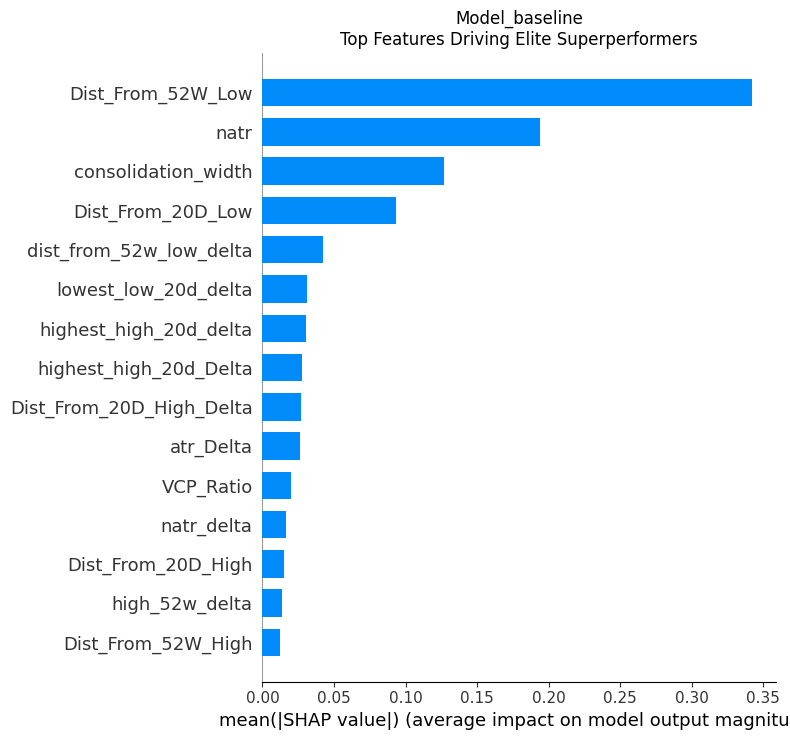

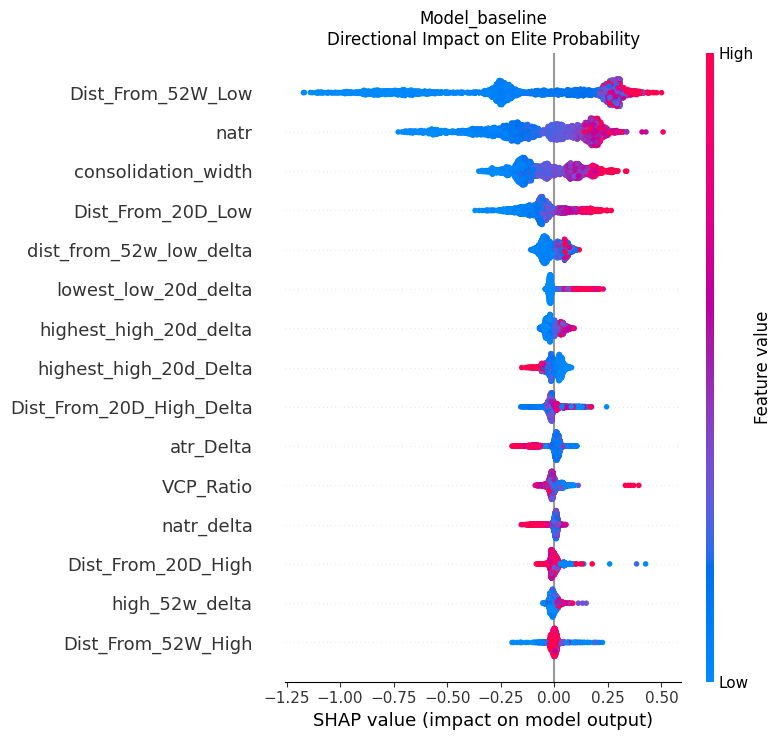

In [90]:
active_groups = [
    # "Moving_Averages", 
    # "Momentum_RS", 
    # "Core_Volume", 
    # "Volatility_Ranges", 
    # "Technical_Oscillators", 
    # "Fundamentals", 
    # "Fast_Alphas", 
    # "M03_Regime"
]
model_b, explainer_b, candidate_features_b = train_and_evaluate_xgboost(
    df, 
    active_groups, 
    # exclude_features=['Dist_From_52W_Low', 'natr'], 
    target_col='target_class', 
    title_prefix="Model_baseline",
    show_plots=True
)

In [95]:
# --- 1. Create MFE Bins (Option B: 4-Class System) ---
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define our MFE Bin edges (Adjust these if your percentiles look vastly different)
# Class 0: Duds (MFE <= 2%)
# Class 1: Noise/Chop (2% < MFE <= 10%)
# Class 2: Solid Trends (10% < MFE <= 30%)
# Class 3: Superperformers (MFE > 30%)

conditions = [
    (df['MFE'] <= 2.0),
    (df['MFE'] > 2.0) & (df['MFE'] <= 10.0),
    (df['MFE'] > 10.0) & (df['MFE'] <= 30.0),
    (df['MFE'] > 30.0)
]
choices = [0, 1, 2, 3]

# Create the target column
df['target_class'] = np.select(conditions, choices, default=np.nan)

# Drop any rows where MFE might have been missing
df = df.dropna(subset=['target_class'])
df['target_class'] = df['target_class'].astype(int)

# Check the class balance
class_counts = df['target_class'].value_counts().sort_index()
class_pcts = df['target_class'].value_counts(normalize=True).sort_index() * 100

print("=== Class Distribution ===")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count} rows ({class_pcts[cls]:.1f}%)")

exclude_cols = [
    # Leakage
    'entry_date', 'exit_date', 'return_pct', 'target', 'days_held', 'return_at_exit',
    'holding_days', 'MAE', 'days_observed', 'MFE', 'exit_price','entry_price', 
    'mae_date', 'mfe_date', 'mae_holding', 'mfe_holding', 'sl_pct', 'sl_date', 'sl_exit_date', 'target_class',
    # raw
    'ticker', 'close', 'market_cap', 'return_adj'
    # high missing value
    'peg_adjusted', 'inventory_vs_sales_spread', 'inventory_growth_yoy'
]
features = [c for c in df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])]
print(f"Number of features: {len(features)}")

# --- 4. Train Baseline XGBoost Classifier (UPDATED) ---

df_xgb = df.dropna(subset=['target_class']).copy()
X = df_xgb[features].replace([np.inf, -np.inf], np.nan) 
y = df_xgb['target_class']
# Standard chronological train/test split (assuming df is already ordered by date)
split_idx = int(len(df_xgb) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
sample_weights = y_train.map(dict(zip(classes, weights)))

# Using enable_categorical=True is required for columns like 'sector' and 'industry'
dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weights, enable_categorical=True)
dtest = xgb.DMatrix(X_test, label=y_test, enable_categorical=True)

params = {
    'objective': 'multi:softmax',
    'num_class': 4,
    'eval_metric': 'mlogloss',
    'max_depth': 4,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

print("\nTraining XGBoost...")
evals = [(dtrain, 'train'), (dtest, 'eval')]
model = xgb.train(params, dtrain, num_boost_round=1000, evals=evals, early_stopping_rounds=50, verbose_eval=100)


=== Class Distribution ===
Class 0: 2712 rows (22.2%)
Class 1: 5114 rows (41.8%)
Class 2: 2991 rows (24.5%)
Class 3: 1416 rows (11.6%)
Number of features: 234

Training XGBoost...
[0]	train-mlogloss:1.33193	eval-mlogloss:1.33979
[100]	train-mlogloss:0.36263	eval-mlogloss:0.50523
[200]	train-mlogloss:0.28208	eval-mlogloss:0.46540
[300]	train-mlogloss:0.23352	eval-mlogloss:0.45847
[400]	train-mlogloss:0.19665	eval-mlogloss:0.45736
[499]	train-mlogloss:0.16679	eval-mlogloss:0.45638


### 2. Hierarchical Feature Exploration (XGBoost-Friendly)

In [96]:
from sklearn.feature_selection import mutual_info_regression
import warnings
warnings.filterwarnings('ignore')

# Hardcoded dictionary based on our feature_hierarchy.md mapping
feature_groups = {
    "Core/Volume": ['Volume', 'Turnover', 'return_1d'],
    "Moving Averages": ['SMA_50', 'Price_vs_SMA_50', 'SMA_150', 'Price_vs_SMA_150', 'SMA_200', 'Price_vs_SMA_200', 'SMA_50_Slope', 'Vol_MA'],
    "Momentum/RS": ['RS', 'RS_MA', 'RS_Lag1', 'RS_MA_Lag1', 'RS_Delta', 'RS_MA_Delta', 'Sector_Momentum', 'Industry_Momentum'],
    "Volatility/Ranges": ['ATR', 'nATR', 'Vol_Ratio', 'High_52W', 'Low_52W', 'High_20D', 'Consolidation_Width', 'Dry_Up_Volume', 'Dist_From_52W_High'],
    "Technical/Oscillators": ['Breakout', 'RSI_14', 'Is_Green_Day', 'Green_Days_Ratio_20D'],
    "Fundamentals/Hybrids": ['pe_ratio', 'ps_ratio', 'pb_ratio', 'peg_adjusted', 'revenue_growth_yoy', 'eps_growth_yoy', 'debt_to_equity'],
    "Fast Alphas": ['alpha001', 'alpha006', 'alpha009', 'alpha012']
}

target_col = 'return_pct' # Ensure this exists in your df

for group_name, cols in feature_groups.items():
    valid_cols = [c for c in cols if c in df.columns]
    
    if len(valid_cols) > 1:
        print(f"\nAnalysing Group: {group_name} ({len(valid_cols)} features)")
        
        # 1. Intra-group Correlation (Spearman still good for finding linear redundancy)
        corr_matrix = df[valid_cols].corr(method='spearman')
        
        redundant_pairs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                if abs(corr_matrix.iloc[i, j]) > 0.85:
                    redundant_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
        
        if redundant_pairs:
            print("  Highly Correlated Pairs (XGBoost can handle them, but watch out for bloated trees):")
            for f1, f2, corr in redundant_pairs:
                print(f"    - {f1} <--> {f2}: {corr:.2f}")
            
        # 2. Mutual Information (Detects Any Non-Linear/Kinked Relationship)
        print("  Mutual Information (Predictive signal strength):")
        # MI requires no NaNs, so we drop NaNs just for this test subset
        mi_df = df[valid_cols + [target_col]].dropna()
        if len(mi_df) > 100:
            mi_scores = mutual_info_regression(mi_df[valid_cols], mi_df[target_col], random_state=42)
            mi_series = pd.Series(mi_scores, index=valid_cols).sort_values(ascending=False)
            print(mi_series.to_string())
        else:
            print("  Not enough clean data to calculate MI.")



Analysing Group: Core/Volume (2 features)
  Mutual Information (Predictive signal strength):
return_1d    0.055109
Volume       0.011236

Analysing Group: Moving Averages (4 features)
  Highly Correlated Pairs (XGBoost can handle them, but watch out for bloated trees):
    - SMA_50 <--> SMA_150: 1.00
    - SMA_50 <--> SMA_200: 1.00
    - SMA_150 <--> SMA_200: 1.00
  Mutual Information (Predictive signal strength):
SMA_200    0.036534
SMA_150    0.030273
SMA_50     0.027134
Vol_MA     0.017950

Analysing Group: Momentum/RS (2 features)
  Mutual Information (Predictive signal strength):
Sector_Momentum      0.023489
Industry_Momentum    0.019041

Analysing Group: Volatility/Ranges (5 features)
  Highly Correlated Pairs (XGBoost can handle them, but watch out for bloated trees):
    - ATR <--> High_52W: 0.92
    - High_52W <--> Low_52W: 0.95
  Mutual Information (Predictive signal strength):
Dist_From_52W_High    0.040765
Low_52W               0.039204
High_52W              0.018432
Dry_

### 3: XGBoost Multi-Class Quick-Train

Class Distribution:
target_class
0.0    22.169541
1.0    41.804954
2.0    24.450258
3.0    11.575247
Name: proportion, dtype: float64

Training Multi-Class XGBoost on 9786 train samples (Testing on 2447)...
XGBoost training complete.

Classification Report on Out-Of-Sample Test Set:
              precision    recall  f1-score   support

         0.0       0.42      0.64      0.50       560
         1.0       0.55      0.31      0.40       968
         2.0       0.35      0.27      0.30       639
         3.0       0.30      0.57      0.39       280

    accuracy                           0.41      2447
   macro avg       0.40      0.45      0.40      2447
weighted avg       0.44      0.41      0.40      2447

Calculating SHAP values...


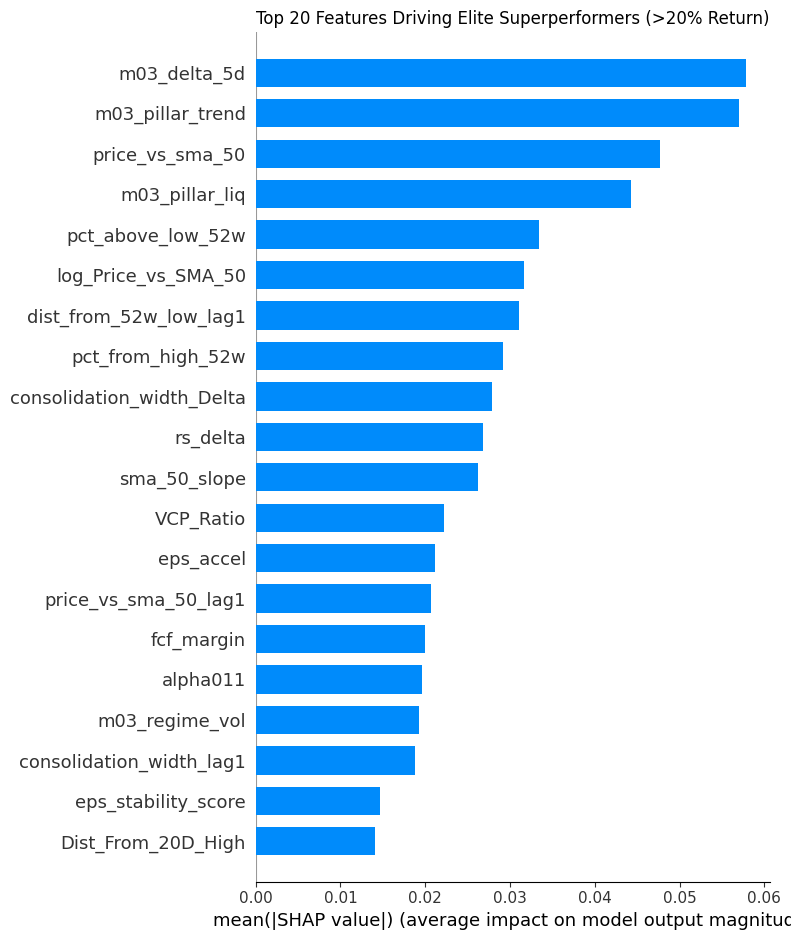

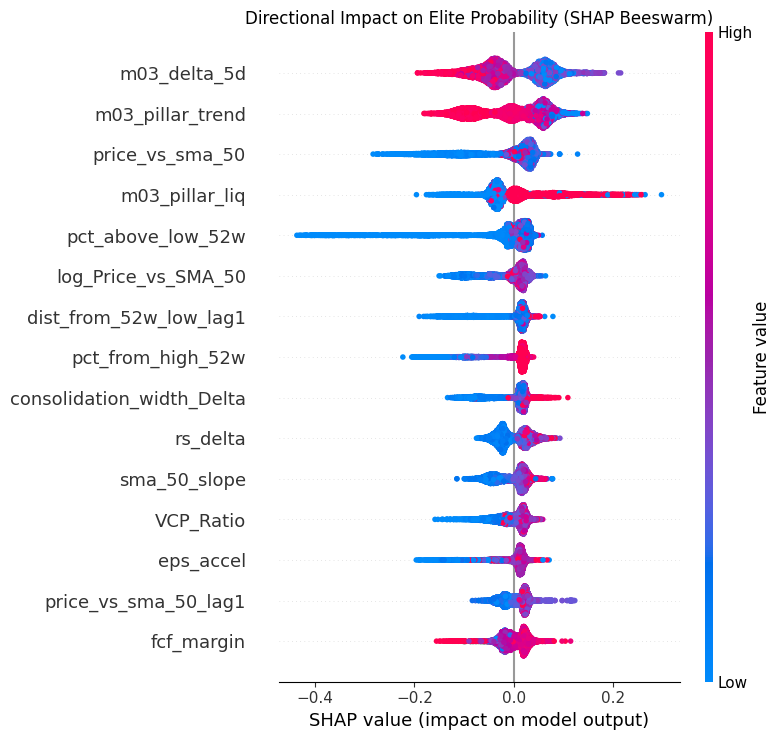

--- SHAP Dependence Plots for Elite Superperformers ---
These show the exact thresholds that separate standard winners from elite winners.


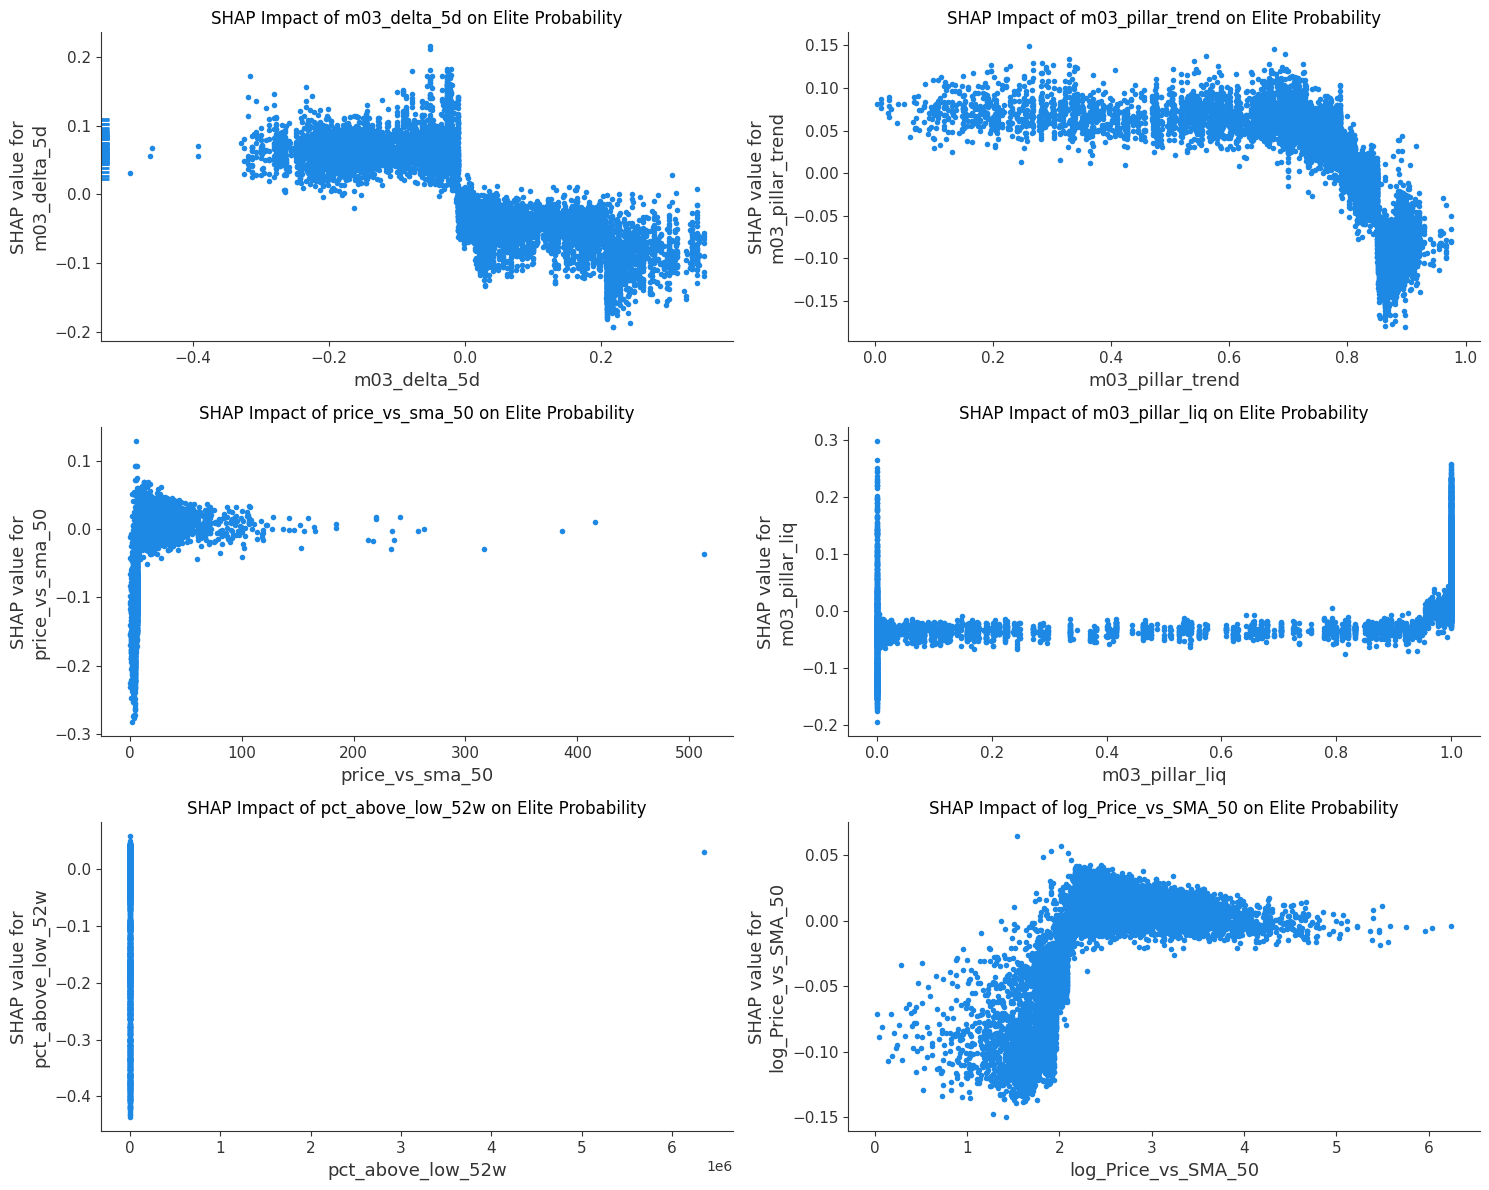

In [98]:
# Define Multi-Class Target based on absolute return thresholds
conditions = [
    (df['MFE'] <= 2.0),
    (df['MFE'] > 2.0) & (df['MFE'] <= 10.0),
    (df['MFE'] > 10.0) & (df['MFE'] <= 30.0),
    (df['MFE'] > 30.0)
]
choices = [0, 1, 2, 3]

# Create the target column
df['target_class'] = np.select(conditions, choices, default=np.nan)

print("Class Distribution:")
print(df['target_class'].value_counts(normalize=True).sort_index() * 100)

feature_groups = {
    "Core/Volume": ['Volume', 'Turnover', 'return_1d'],
    "Moving Averages": ['SMA_50', 'Price_vs_SMA_50', 'SMA_150', 'Price_vs_SMA_150', 'SMA_200', 'Price_vs_SMA_200', 'SMA_50_Slope', 'Vol_MA'],
    "Momentum/RS": ['RS', 'RS_MA', 'RS_Lag1', 'RS_MA_Lag1', 'RS_Delta', 'RS_MA_Delta', 'Sector_Momentum', 'Industry_Momentum'],
    "Volatility/Ranges": ['ATR', 'nATR', 'Vol_Ratio', 'High_52W', 'Low_52W', 'High_20D', 'Consolidation_Width', 'Dry_Up_Volume', 'Dist_From_52W_High'],
    "Technical/Oscillators": ['Breakout', 'RSI_14', 'Is_Green_Day', 'Green_Days_Ratio_20D'],
    "Fundamentals/Hybrids": ['pe_ratio', 'ps_ratio', 'pb_ratio', 'peg_adjusted', 'revenue_growth_yoy', 'eps_growth_yoy', 'debt_to_equity'],
    "Fast Alphas": ['alpha001', 'alpha006', 'alpha009', 'alpha012']
}


# Start with ALL numeric features (exclude metadata and target-leak columns)
exclude_cols = [
    # Leakage
    'entry_date', 'exit_date', 'return_pct', 'target', 'days_held', 'return_at_exit',
    'holding_days', 'MAE', 'days_observed', 'MFE', 'exit_price','entry_price', 
    'mae_date', 'mfe_date', 'mae_holding', 'mfe_holding', 'return_adj',
    # raw
    'ticker', 'close', 'market_cap', 'target_class'
]
candidate_features = [c for c in df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])]

# Drop rows missing the target.
df_xgb = df.dropna(subset=['target_class']).copy()
X = df_xgb[candidate_features].replace([np.inf, -np.inf], np.nan) 
y = df_xgb['target_class']

# Standard chronological train/test split (assuming df is already ordered by date)
split_idx = int(len(df_xgb) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
print(f"\nTraining Multi-Class XGBoost on {len(X_train)} train samples (Testing on {len(X_test)})...")
# Calculate class weights for imbalance
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
weight_dict = dict(zip(classes, weights))
sample_weights = y_train.map(weight_dict)
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,         
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=4, # Fixed to 4 classes
    random_state=42,
    n_jobs=-1
)
# Fit WITH sample_weights applied to the training set
model.fit(X_train, y_train, sample_weight=sample_weights)
print("XGBoost training complete.")
# Quick evaluation
from sklearn.metrics import classification_report
preds = model.predict(X_test)
print("\nClassification Report on Out-Of-Sample Test Set:")
print(classification_report(y_test, preds))

print("Calculating SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# For a multi-class model, SHAP returns a list of arrays (one for each class)
# We ONLY care about what drives Class 2 (The Elite Superperformers)
# Note: depending on shap version, it might return a 3D array instead of a list
if isinstance(shap_values, list):
    shap_values_elite = shap_values[2] 
else:
    shap_values_elite = shap_values[:, :, 2]

# 1. Global Bar Plot for Class 2
plt.figure(figsize=(10, 6))
plt.title("Top 20 Features Driving Elite Superperformers (>20% Return)")
shap.summary_plot(shap_values_elite, X, plot_type="bar", max_display=20)

# 2. Summary Beeswarm Plot for Class 2
# Red = High Value, Blue = Low Value. 
# Right of center = INCREASES probability of the trade becoming an Elite Superperformer
plt.figure(figsize=(10, 6))
plt.title("Directional Impact on Elite Probability (SHAP Beeswarm)")
shap.summary_plot(shap_values_elite, X, plot_type="dot", max_display=15)

# 3. Dependence Plots for Top Features (Class 2)
# Calculate the average absolute SHAP value to find the top 6 features for Class 2
top_features_indices = np.argsort(np.abs(shap_values_elite).mean(0))[-6:] 
top_feature_names = [X.columns[i] for i in reversed(top_features_indices)]

print("--- SHAP Dependence Plots for Elite Superperformers ---")
print("These show the exact thresholds that separate standard winners from elite winners.")

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, f in enumerate(top_feature_names):
    shap.dependence_plot(f, shap_values_elite, X, ax=axes[i], interaction_index=None, show=False)
    axes[i].set_title(f"SHAP Impact of {f} on Elite Probability")

plt.tight_layout()
plt.show()


#### Test out only regressing on fundamentals

In [ ]:
# --- 1. Explicitly Blacklist the Technical/Reversion Groups ---
technical_blacklist = [
    # Group 2: Moving Averages (These cause heavy reversion bias)
    'SMA_50', 'Price_vs_SMA_50', 'SMA_150', 'Price_vs_SMA_150', 
    'SMA_200', 'Price_vs_SMA_200', 'SMA_50_Slope', 'Vol_MA',
    # Note: If you have dynamic variants like Price_vs_SMA_50_Delta, add them here too
    'Price_vs_SMA_50_Delta', 'Price_vs_SMA_150_Delta', 'Price_vs_SMA_200_Delta',
    
    # Group 4: Volatility/Ranges (Except the 52W High/Low breakouts, let's kill the ATR chop)
    'ATR', 'nATR', 'Vol_Ratio', 'Consolidation_Width', 'natr_delta', 'vcp_ratio_delta', 
    # Optional: Keep VCP_Ratio if you want to let the model see the contraction, 
    # but we can kill it to be purely fundamental here:
    'VCP_Ratio', 'm03_regime_vol', 
    # Group 5: Technical/Oscillators
    'RSI_14', 'Is_Green_Day', 'Green_Days_Ratio_20D', 
    
    # Group 7: Fast Alphas (These predict MAE/Drawdowns, not long-term MFE trends)
    'alpha001', 'alpha006', 'alpha009', 'alpha012', 'alpha054'
]
# Combine with our baseline leakage exclusions
leakage_cols = [
    # Leakage / Targets
    'entry_date', 'exit_date', 'return_pct', 'target', 'days_held', 'return_at_exit',
    'holding_days', 'MAE', 'days_observed', 'MFE', 'exit_price', 'entry_price', 
    'mae_date', 'mfe_date', 'mae_holding', 'mfe_holding',
    # Raw / Identifiers
    'ticker', 'close', 'market_cap', 'target_class'
]
datetime_cols = [c for c in df.columns if pd.api.types.is_datetime64_any_dtype(df[c])]
# Final Exclusion Set
exclude_cols = list(set(leakage_cols + technical_blacklist + datetime_cols + ['trade_id', 'feature_version']))
# Select features that SURVIVE the blacklist
candidate_features = [c for c in df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])]
print(f"Features pruned from Baseline to force Fundamental Splits: {len(df.columns) - len(candidate_features)}")
# --- 2. Train the SEPA-like Fundamental & Momentum Model ---
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
from sklearn.metrics import classification_report
df_xgb = df.dropna(subset=['target_class']).copy()
X = df_xgb[candidate_features].replace([np.inf, -np.inf], np.nan) 
y = df_xgb['target_class']
# Standard chronological train/test split
df_xgb = df_xgb.sort_values('entry_date')
split_idx = int(len(df_xgb) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
print(f"\nTraining Pure Fundamental/Momentum XGBoost on {len(X_train)} samples with {len(candidate_features)} features...")
# Calculate class weights for imbalance
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
weight_dict = dict(zip(classes, weights))
sample_weights = y_train.map(weight_dict)
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,         
    learning_rate=0.05,        # Lowered slightly for stability on harder fundamental splits
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=4, 
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train, sample_weight=sample_weights)
print("XGBoost training complete.")
# --- 3. Evaluate ---
preds = model.predict(X_test)
print("\nClassification Report (Fundamental/Momentum Model):")
print(classification_report(y_test, preds))

# --- 4. The Moment of Truth: New SHAP Plot (FIXED) ---
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Check if shap_values is a list (older versions) or a 3D numpy array (newer versions)
if isinstance(shap_values, list):
    # Old version: It's a list where index 3 holds Class 3
    shap_vals_class3 = shap_values[3] 
else:
    # New version: It's a 3D array (samples, features, classes)
    shap_vals_class3 = shap_values[:, :, 3]

plt.figure(figsize=(10, 8))
# Target Class 3 is the Superperformers
shap.summary_plot(shap_vals_class3, X_test, plot_type="bar", max_display=20, show=False)
plt.title("Top 20 Features Driving Elite Superperformers (>30% MFE)\n(Fundamental/Momentum Run)")
plt.tight_layout()
plt.show()

# Since we want to reverse-engineer his SEPA logic, let's also look at the direct impact:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals_class3, X_test, max_display=15, show=False)
plt.title("Superperformer Directional SHAP (Fundamental Run)")
plt.tight_layout()
plt.show()


In [ ]:
# --- 1. Pure Fundamentals Whitelist ---
# We explicitly define the exact columns XGBoost is allowed to see.
fundamental_whitelist = [
    # Valuation Ratios
    'pe_ratio', 'ps_ratio', 'pb_ratio', 'peg_adjusted',
    
    # Growth & Health
    'revenue_growth_yoy', 'eps_growth_yoy', 'debt_to_equity',
    'earnings_quality_score', 'revenue_cagr_3y',
    
    # Size/Scale
    'market_cap', 'total_equity' 
    
    # Add any other purely fundamental columns you have in df here!
    # (Do NOT add RS, Momentum, or Price distance metrics)
]
exclude_cols = [
    # Leakage
    'entry_date', 'exit_date', 'return_pct', 'target', 'days_held', 'return_at_exit',
    'holding_days', 'MAE', 'days_observed', 'MFE', 'exit_price','entry_price', 
    'mae_date', 'mfe_date', 'mae_holding', 'mfe_holding',
    # raw
    'ticker', 'close', 'market_cap', 'target_class'
]
# Ensure the required target tracking columns exist for the split logic
candidate_features = [c for c in df.columns if c in fundamental_whitelist ]

print(f"Features restricted to Pure Fundamentals: {len(candidate_features)}")
print(f"Whitelist used: {candidate_features}\n")

# --- 2. Train the Pure Fundamental Model ---
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
from sklearn.metrics import classification_report

df_xgb = df.dropna(subset=['target_class']).copy()
X = df_xgb[candidate_features].replace([np.inf, -np.inf], np.nan) 
y = df_xgb['target_class']

# Standard chronological train/test split
df_xgb = df_xgb.sort_values('entry_date')
split_idx = int(len(df_xgb) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training Pure Fundamental XGBoost on {len(X_train)} samples...\n")

# Calculate class weights for imbalance
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
weight_dict = dict(zip(classes, weights))
sample_weights = y_train.map(weight_dict)

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,               # Dropped depth to 3 to prevent overfitting sparse quarterly data
    learning_rate=0.05,        
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=4, 
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train, sample_weight=sample_weights)

# --- 3. Evaluate ---
preds = model.predict(X_test)
print("Classification Report (Pure Fundamentals Model):")
print(classification_report(y_test, preds))

# --- 4. SHAP Plot ---
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_vals_class3 = shap_values[3] 
else:
    shap_vals_class3 = shap_values[:, :, 3]

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals_class3, X_test, plot_type="bar", max_display=15, show=False)
plt.title("Top Fundamental Features Driving Superperformers (>30% MFE)")
plt.tight_layout()
plt.show()

# Directional Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals_class3, X_test, max_display=15, show=False)
plt.title("Superperformer Directional SHAP (Pure Fundamentals)")
plt.tight_layout()
plt.show()


In [ ]:
def train_and_evaluate_xgboost(raw_df, active_groups, target_col='target_class', title_prefix="MFE Model"):
    """
    Trains an XGBoost multiclass model using only features from the specified groups.
    Outputs the classification report and 3 SHAP plots for Class 3 (Superperformers).
    """
    print(f"=== Starting Run: {title_prefix} ===")
    
    # Build a flat list of all allowed features (lowercase to catch mismatches)
    active_whitelist = []
    for group in active_groups:
        active_whitelist.extend([f.lower() for f in FEATURE_GROUPS[group]])
        
    explicit_drop_cols = [
        'entry_date', 'exit_date', 'return_pct', 'target', 'days_held', 'return_at_exit',
        'holding_days', 'MAE', 'days_observed', 'MFE', 'exit_price','entry_price', 
        'mae_date', 'mfe_date', 'mae_holding', 'mfe_holding', 'ticker', 'close', target_col
    ]
    
    # Filter the dataframe safely
    candidate_features = [c for c in raw_df.columns if c.lower() in active_whitelist 
                          and c not in explicit_drop_cols 
                          and pd.api.types.is_numeric_dtype(raw_df[c])]
    
    df_clean = raw_df.dropna(subset=[target_col]).copy()
    X = df_clean[candidate_features].replace([np.inf, -np.inf], np.nan) 
    y = df_clean[target_col]
    
    # Split
    df_clean = df_clean.sort_values('entry_date') if 'entry_date' in df_clean.columns else df_clean
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    print(f"Training on {len(X_train)} samples using {len(candidate_features)} features from groups: {active_groups}")
    
    # Imbalance Weights
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    sample_weights = y_train.map(dict(zip(classes, weights)))
    
    # Train
    model = xgb.XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, objective='multi:softprob',
        num_class=4, random_state=42, n_jobs=-1
    )
    model.fit(X_train, y_train, sample_weight=sample_weights)
    
    # Eval
    preds = model.predict(X_test)
    print("\n--- Classification Report (Out-of-Sample) ---")
    print(classification_report(y_test, preds))
    
    # SHAP Generation (ONLY on X_test to prevent memory crashes)
    print("\nCalculating SHAP values...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    
    # Handle older vs newer shap version return shapes
    shap_values_elite = shap_values[3] if isinstance(shap_values, list) else shap_values[:, :, 3]
    
    # Plot 1: Global Bar
    plt.figure(figsize=(10, 6))
    plt.title(f"{title_prefix}: Top Features Driving Elite Superperformers")
    shap.summary_plot(shap_values_elite, X_test, plot_type="bar", max_display=15, show=False)
    plt.tight_layout()
    plt.show()

    # Plot 2: Directional Dot Plot
    plt.figure(figsize=(10, 6))
    plt.title(f"{title_prefix}: Directional Impact on Elite Probability")
    shap.summary_plot(shap_values_elite, X_test, plot_type="dot", max_display=15, show=False)
    plt.tight_layout()
    plt.show()
    
    return model, explainer

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

# --- 1. Target Definition (Run once) ---
conditions = [
    (df['MFE'] <= 2.0),
    (df['MFE'] > 2.0) & (df['MFE'] <= 10.0),
    (df['MFE'] > 10.0) & (df['MFE'] <= 30.0),
    (df['MFE'] > 30.0)
]
df['target_class'] = np.select(conditions, [0, 1, 2, 3], default=np.nan)

# --- 2. Centralized Master Feature Dictionary ---
FEATURE_GROUPS = {
    "Core_Volume": ['Volume', 'Turnover', 'return_1d', 'return_5d', 'log_volume_velocity'],
    "Moving_Averages": ['SMA_50', 'price_vs_sma_50', 'Price_vs_SMA_50_Delta', 'SMA_150', 
        'price_vs_sma_150', 'SMA_200', 'price_vs_sma_200', 'sma_50_slope', 'Vol_MA'],
    "Momentum_RS": ['RS', 'RS_MA', 'RS_Lag1', 'RS_MA_Lag1', 'RS_Delta', 'rs_delta', 
        'RS_MA_Delta', 'Sector_Momentum', 'Industry_Momentum', 'RS_vs_Industry', 
        'RS_vs_Sector', 'RS_Universe_Rank', 'mom_126d'],
    "Volatility_Ranges": ['ATR', 'nATR', 'natr_delta', 'Vol_Ratio', 'High_52W', 'Low_52W', 
        'high_20d', 'adr_20d', 'Consolidation_Width', 'consolidation_width_lag1', 'Dry_Up_Volume', 
        'Dist_From_52W_High', 'dist_from_52w_high_lag1', 'Dist_From_52W_Low', 'dist_from_52w_low_lag1', 
        'Dist_From_20D_Low', 'pct_above_low_52w', 'VCP_Ratio', 'vcp_ratio_delta', 'm03_regime_vol'],
    "Technical_Oscillators": ['Breakout', 'RSI_14', 'Is_Green_Day', 'Green_Days_Ratio_20D'],
    "Fundamentals": ['pe_ratio', 'ps_ratio', 'pb_ratio', 'peg_adjusted', 'revenue_growth_yoy', 
        'eps_growth_yoy', 'debt_to_equity', 'earnings_quality_score', 'total_equity', 'market_cap', 
        'revenue_cagr_3y'],
    "Fast_Alphas": ['alpha001', 'log_alpha001', 'alpha006', 'alpha009', 'alpha012', 'alpha013', 
        'alpha041', 'alpha054'],
    "M03": ['m03_pillar_liq', 'm03_delta_5d', 'm03_pillar_risk']
}



In [ ]:
# Full Suite
full_groups = [
    "Core_Volume", "Moving_Averages", "Momentum_RS", "Volatility_Ranges", 
    "Technical_Oscillators", "Fast_Alphas", "M03", "Fundamentals"
]
model_tech, explainer_tech = train_and_evaluate_xgboost(
    df, 
    active_groups=full_groups, 
    title_prefix="Pure Technical Model"
)

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

# --- 1. Target Definition (Run once) ---
conditions = [
    (df['MFE'] <= 2.0),
    (df['MFE'] > 2.0) & (df['MFE'] <= 10.0),
    (df['MFE'] > 10.0) & (df['MFE'] <= 30.0),
    (df['MFE'] > 30.0)
]
# Create the target column if it doesn't already exist
if 'target_class' not in df.columns:
    df['target_class'] = np.select(conditions, [0, 1, 2, 3], default=np.nan)

print("Class Distribution:")
print(df['target_class'].value_counts(normalize=True).sort_index() * 100)

# --- 2. Centralized Master Feature Dictionary ---
FEATURE_GROUPS = {
    "Core_Volume": ['Volume', 'Turnover', 'return_1d', 'return_5d', 'log_volume_velocity'],
    "Moving_Averages": ['SMA_50', 'price_vs_sma_50', 'Price_vs_SMA_50_Delta', 'SMA_150', 'price_vs_sma_150', 'SMA_200', 'price_vs_sma_200', 'sma_50_slope', 'Vol_MA'],
    "Momentum_RS": ['RS', 'RS_MA', 'RS_Lag1', 'RS_MA_Lag1', 'RS_Delta', 'rs_delta', 'RS_MA_Delta', 'Sector_Momentum', 'Industry_Momentum', 'RS_vs_Industry', 'RS_vs_Sector', 'RS_Universe_Rank', 'mom_126d'],
    "Volatility_Ranges": ['ATR', 'nATR', 'natr_delta', 'Vol_Ratio', 'High_52W', 'Low_52W', 'high_20d', 'adr_20d', 'Consolidation_Width', 'consolidation_width_lag1', 'Dry_Up_Volume', 'Dist_From_52W_High', 'dist_from_52w_high_lag1', 'Dist_From_52W_Low', 'dist_from_52w_low_lag1', 'Dist_From_20D_Low', 'pct_above_low_52w', 'VCP_Ratio', 'vcp_ratio_delta', 'm03_regime_vol'],
    "Technical_Oscillators": ['Breakout', 'RSI_14', 'Is_Green_Day', 'Green_Days_Ratio_20D'],
    "Fundamentals": ['pe_ratio', 'ps_ratio', 'pb_ratio', 'peg_adjusted', 'revenue_growth_yoy', 'eps_growth_yoy', 'debt_to_equity', 'earnings_quality_score', 'total_equity', 'market_cap', 'revenue_cagr_3y'],
    "Fast_Alphas": ['alpha001', 'log_alpha001', 'alpha006', 'alpha009', 'alpha012', 'alpha013', 'alpha041', 'alpha054'],
    "Sprint4_M03": ['m03_pillar_liq', 'm03_delta_5d', 'm03_pillar_risk']
}

# --- 3. The Modular Training & Plotting Function ---
def train_and_evaluate_xgboost(raw_df, active_groups, exclude_features=None, target_col='target_class', title_prefix="MFE Model"):
    """
    Trains an XGBoost multiclass model using only features from the specified groups.
    
    Parameters:
    - raw_df: The overarching pandas DataFrame.
    - active_groups: A list of keys from FEATURE_GROUPS to include.
    - exclude_features: A list of specific feature names to DROP, even if they are in an active group.
    - target_col: The column containing the labels (0, 1, 2, 3).
    - title_prefix: String to prepend to all the SHAP plot titles.
    """
    print(f"\n{'='*50}\n=== Starting Run: {title_prefix} ===\n{'='*50}")
    
    # Clean up exclusion list
    exclude_features = [f.lower() for f in exclude_features] if exclude_features else []
    
    # Build a flat list of all allowed features from the active groups (lowercase to catch mismatches)
    active_whitelist = []
    for group in active_groups:
        active_whitelist.extend([f.lower() for f in FEATURE_GROUPS[group]])
        
    explicit_drop_cols = [
        'entry_date', 'exit_date', 'return_pct', 'target', 'days_held', 'return_at_exit',
        'holding_days', 'MAE', 'days_observed', 'MFE', 'exit_price','entry_price', 
        'mae_date', 'mfe_date', 'mae_holding', 'mfe_holding', 'ticker', 'close', target_col
    ]
    
    # 1. Start with the raw columns
    # 2. Keep if it exists in our active_groups whitelist
    # 3. Drop if it exists in the explicit_drop_cols (Leakage)
    # 4. Drop if the user explicitly requested it in exclude_features
    # 5. Drop if it's not numbers
    candidate_features = [
        c for c in raw_df.columns 
        if c.lower() in active_whitelist 
        and c not in explicit_drop_cols 
        and c.lower() not in exclude_features
        and pd.api.types.is_numeric_dtype(raw_df[c])
    ]
    
    print(f"-> Active Feature Groups ({len(active_groups)}): {active_groups}")
    if exclude_features:
        print(f"-> Explicitly Excluded Features ({len(exclude_features)}): {exclude_features}")
        
    print(f"-> Final Feature Count Fed to XGBoost: {len(candidate_features)}")
    print(f"-> Features Used:\n{candidate_features}\n")
    
    df_clean = raw_df.dropna(subset=[target_col]).copy()
    X = df_clean[candidate_features].replace([np.inf, -np.inf], np.nan) 
    y = df_clean[target_col]
    
    # Split
    df_clean = df_clean.sort_values('entry_date') if 'entry_date' in df_clean.columns else df_clean
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    print(f"Training on {len(X_train)} train samples (Testing on {len(X_test)})...")
    
    # Imbalance Weights
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    sample_weights = y_train.map(dict(zip(classes, weights)))
    
    # Train
    model = xgb.XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, objective='multi:softprob',
        num_class=len(classes), random_state=42, n_jobs=-1
    )
    model.fit(X_train, y_train, sample_weight=sample_weights)
    
    # Eval
    preds = model.predict(X_test)
    print("\n--- Classification Report (Out-of-Sample) ---")
    print(classification_report(y_test, preds))
    
    # SHAP Generation (ONLY on X_test to prevent memory crashes)
    print("\nCalculating SHAP values...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    
    # Handle older vs newer shap version return shapes. Target Class 3 (Superperformers).
    shap_values_elite = shap_values[3] if isinstance(shap_values, list) else shap_values[:, :, 3]
    
    # Plot 1: Global Bar
    plt.figure(figsize=(10, 6))
    plt.title(f"{title_prefix}\nTop Features Driving Elite Superperformers")
    shap.summary_plot(shap_values_elite, X_test, plot_type="bar", max_display=15, show=False)
    plt.tight_layout()
    plt.show()

    # Plot 2: Directional Dot Plot
    plt.figure(figsize=(10, 6))
    plt.title(f"{title_prefix}\nDirectional Impact on Elite Probability")
    shap.summary_plot(shap_values_elite, X_test, plot_type="dot", max_display=15, show=False)
    plt.tight_layout()
    plt.show()
    
    return model, explainer


In [ ]:
technical_groups = [
    "Core_Volume", "Moving_Averages", "Volatility_Ranges", 
    "Technical_Oscillators", "Fast_Alphas", "Sprint4_M03"
]

model_tech, expl_tech = train_and_evaluate_xgboost(
    df, 
    active_groups=technical_groups, 
    exclude_features=['revenue_cagr_3y', 'pe_ratio'], 
    title_prefix="Pure Technical Model"
)


In [ ]:
fundamental_groups = ["Fundamentals", "Momentum_RS"]

model_fund, expl_fund = train_and_evaluate_xgboost(
    df, 
    active_groups=fundamental_groups, 
    title_prefix="Minervini Stage 1 Equivalent (Health & Momentum)"
)


### 4. Feature Engineering

In [ ]:
# 6. Feature Selection & XGBoost Classifier Training
import pandas as pd
import numpy as np
from src.train_model import SEPAModelTrainer
from src.model_preparation import TemporalSplitter 

print("1. Removing perfectly correlated redundant features...")
# From our EDA, these two are r > 0.98 correlated with dist_from_52w_low_lag1, 
# but dist_from_52w_low_lag1 has much higher SHAP importance.
features_to_drop = ['Dist_From_52W_Low', 'pct_above_low_52w']

# Define our finalized list of features to train on
final_features = [f for f in available_top_features if f not in features_to_drop]
print(f"Final Feature Count: {len(final_features)}")

# We need a binary target for classification. 
# Defining 'Elite Superperformer' as > 20% return based on previous EDA context.
target_col = 'is_elite'
if target_col not in df_transformed.columns:
    df_transformed[target_col] = (df_transformed['return_pct'] > 0.20).astype(int)

# Drop any remaining NaNs in our feature set before feeding to XGBoost
df = df_transformed.dropna(subset=final_features + [target_col, 'entry_date']).copy()
print(f"Rows ready for training: {len(df)}")

print("\n2. Initializing Temporal Splitter (Walk-Forward Validation)...")
# Sort securely by time
df = df.sort_values('entry_date').reset_index(drop=True)

# Simple Time Series Split (80% Train / 20% Validation) for this prototype
train_size = int(len(df) * 0.8)

X_train = df.iloc[:train_size][final_features]
y_train = df.iloc[:train_size][target_col]

X_val = df.iloc[train_size:][final_features]
y_val = df.iloc[train_size:][target_col]

print(f"Training Set: {X_train.index.min()} to {X_train.index.max()} ({len(X_train)} samples)")
print(f"Validation Set: {X_val.index.min()} to {X_val.index.max()} ({len(X_val)} samples)")

print("\n3. Training SEPAModelTrainer (XGBoost Classifier)...")
# Initialize the trainer designed specifically for Precision@20%
trainer = SEPAModelTrainer(
    precision_k_pct=0.2, 
    max_depth_limit=4, 
    random_state=42
)

# Train the baseline model (No hyperparameter tuning yet, just fast feedback)
model = trainer.train_baseline(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)

print("\n4. Evaluating Validation Precision@20%...")
# Predict probabilities on the out-of-sample validation set
val_probs = trainer.predict_proba(X_val)

# Calculate how many trades represent the "Top 20%" of our validation set
k = max(1, int(len(val_probs) * 0.2))

# Find the indices of the highest probability predictions
top_k_indices = np.argsort(val_probs)[-k:]

# What was our actual win-rate on the trades the model was MOST confident in?
baseline_win_rate = y_val.mean()
model_win_rate = y_val.iloc[top_k_indices].mean()

print(f"Baseline probability of an Elite trade in Val test: {baseline_win_rate*100:.2f}%")
print(f"Model Precision (Win rate of Top 20% highest conf): {model_win_rate*100:.2f}%")
print(f"Lift Over Baseline: {model_win_rate / baseline_win_rate:.2f}x")


In [ ]:
# 7. Model Diagnostics & SHAP Explainer
import shap
import matplotlib.pyplot as plt

print("1. Plotting Prediction Confidence Distribution...")
plt.figure(figsize=(10, 4))
plt.hist(val_probs, bins=50, color='skyblue', edgecolor='black')
plt.axvline(np.percentile(val_probs, 80), color='red', linestyle='dashed', linewidth=2, label='Top 20% Threshold')
plt.title("Distribution of Model Confidence Scores (Out of Sample)")
plt.xlabel("Predicted Probability of >20% Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print("\n2. Generating SHAP Feature Importance (What the model actually learned)...")
# Initialize the Tree explainer using our custom XGBoost model
explainer = shap.TreeExplainer(trainer.model)

# Compute SHAP values on the Validation set (We want to see what mattered Out-Of-Sample)
shap_values = explainer.shap_values(X_val)

# 1. Standard Bar Plot for raw importance magnitude
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Validation Set)")
plt.show()

# 2. Beeswarm Plot for directional impact
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val, show=False)
plt.title("Directional Impact of Features (Beeswarm)")
plt.show()


to-do
1. alpha001 - its calculation, discrete?
2. sector momentum, why outlier
3. decide if use classifier for M01

to-do
1. how ready is the universe backfill? do we have everything for feature calc?
2. do we save it in the same table?
3. once ready, backfill features, d1, d2 with selected features
4. might need to buy 1 more month from FMP? or whereelse can we get fundamental?

## Appendix

XGBoost model does not care about outliers or skewness as its focus is on ranking. The following transformation is for visualisation.

In [ ]:
# Distribution Profiling (Finding the Fat Tails)
from scipy import stats

# Get all numeric columns (excluding obvious non-features)
exclude_cols = ['ticker', 'entry_date', 'exit_date', 'return_pct', 'target', 'days_held', 'sector_id', 'industry_id']
features = [c for c in df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])]

# Calculate distribution metrics
dist_stats = []
for f in features:
    series = df[f].dropna()
    if len(series) > 100:  # Need minimum sample size
        dist_stats.append({
            'Feature': f,
            'Mean': series.mean(),
            'Std': series.std(),
            'Skewness': stats.skew(series),
            'Kurtosis': stats.kurtosis(series),
            'Min': series.min(),
            'Max': series.max(),
            # '1%': series.quantile(0.01),
            # '99%': series.quantile(0.99)
        })

dist_df = pd.DataFrame(dist_stats).set_index('Feature')

# Display the top 15 most "explosive" features (highest kurtosis)
print("Top 15 features with the fattest tails (High Kurtosis):")
display(dist_df.sort_values('Kurtosis', ascending=False).head(15))

# Display the 15 most skewed features
print("\nTop 15 most skewed features:")
display(dist_df.sort_values('Skewness', key=abs, ascending=False).head(15))


In [ ]:
# Step 3: Visualizing the Extremes
# Pick a few "normal" features and a few "explosive" features based on the table above
# Replace these with actual feature names from your dataset
normal_features = dist_df.sort_values('Kurtosis').head(5).index.tolist()
fat_tail_features = dist_df.sort_values('Kurtosis', ascending=False).head(5).index.tolist()

features_to_plot = normal_features + fat_tail_features

fig, axes = plt.subplots(len(features_to_plot), 2, figsize=(15, 4 * len(features_to_plot)))

for i, f in enumerate(features_to_plot):
    series = df[f].dropna()
    
    # Histogram
    sns.histplot(series, bins=50, ax=axes[i, 0], kde=True)
    axes[i, 0].set_title(f"Histogram: {f}")
    
    # Boxplot (great for seeing outliers)
    sns.boxplot(x=series, ax=axes[i, 1])
    axes[i, 1].set_title(f"Boxplot: {f}")

plt.tight_layout()
plt.show()

In [ ]:
# Global Transformation
def signed_log(x):
    """
    Log transform that handles negative values and 0.
    Preserves the sign, but compresses massive outliers into a readable scale.
    """
    return np.sign(x) * np.log1p(np.abs(x))

# Only target features explicitly proven to have massive right-tail outliers in the EDA graphs
features_to_transform = [
    'Sector_Momentum',          # SHAP plot shows massive outlier > 4000
    'dist_from_52w_low_lag1',   # Histogram shows max > 600
    'Dist_From_52W_Low',        # Histogram shows max > 700 
    'rs_delta'                  # Histogram shows max > 1100
]

# Ensure we only try to transform features actually present in your current dataframe
features_to_transform = [f for f in features_to_transform if f in df.columns]

if not features_to_transform:
    print("Warning: None of the target features to transform were found in the dataframe.")
    df_transformed = df.copy()
else:
    print(f"Analyzing {len(features_to_transform)} features for transformation...")

    # --- Apply Transformation ---
    df_transformed = df.copy()
    for feature in features_to_transform:
        # Applying Signed Log transformation
        df_transformed[feature] = signed_log(df_transformed[feature])
        print(f"✅ Applied Signed Log Transform to: {feature}")

    # --- Plot AFTER Transformation ---
    fig, axes = plt.subplots(len(features_to_transform), 2, figsize=(16, 4 * len(features_to_transform)))
    if len(features_to_transform) == 1:
        axes = [axes]
        
    for i, feature in enumerate(features_to_transform):
        sns.histplot(df_transformed[feature], ax=axes[i][0], bins=100, kde=True, color='lightgreen')
        axes[i][0].set_title(f'AFTER (Signed Log): {feature} Histogram')
        
        sns.boxplot(x=df_transformed[feature], ax=axes[i][1], color='lightgreen')
        axes[i][1].set_title(f'AFTER (Signed Log): {feature} Boxplot')
        
    plt.tight_layout()
    plt.show()
